# Notebook 2 of 3 -- Project Walkthrough, Part 1: Replicating an Egocentric Face-Redaction Pipeline and a Baseline Audit

This is the second notebook in a three-part portfolio series built around an Upwork job posting
("Face redaction for egocentric household video"). The client licenses head-mounted (4K, ~30 fps)
video of household cleaning to robotics / embodied-AI companies and needs an unattended CLI that
irreversibly blurs every face before footage leaves their systems, with **recall >= 99% per face
instance**, **precision >= 95%**, and minimum **$/video-hour**. They cannot measure recall today
because their own sample happens to contain no faces -- so *how you would prove 99%* matters as
much as the pipeline itself.

**This notebook is a draft scaffold, not a finished product.** Everything below runs on a
**synthetic** corpus with known latent ground truth, built here so that recall/precision claims
are checkable facts about the generator rather than plausible-sounding guesses. One small **real**
CPU smoke test (an actual OpenCV YuNet face detector and an actual ffmpeg encode) is included in
`## 4` and is clearly separated from the synthetic simulation. Nothing here should be read as
production experience on the client's real footage. The notebook ends with an explicit
limitations and open-engineering-choices section.

What this notebook does:
1. Builds a synthetic egocentric video corpus with **known** face-instance ground truth, including
   deliberately hard cases (children, mirrors, tiny/occluded faces, TV/photo faces).
2. Runs a naive per-frame detector baseline and shows it **fails** the strict 99% instance-recall
   bar, the way the client says off-the-shelf options do.
3. Adds tracking, temporal padding and a box margin (all **derived here** -- not from any of the
   three papers) and shows how far that gets the trade-off between recall and false blurs. It also
   scores the same detections under both screen/photo-redaction policies and decomposes the false
   blurring by cause (detector clutter vs. a definitional choice vs. the cost of padding).
4. Runs one small **real** CPU smoke test: YuNet face detection at several face sizes/resolutions,
   ffmpeg decode/encode throughput at 4K, and blur-method cost.
5. Audits the client's actual situation (an all-zero-face sample proves nothing) and shows honest
   Clopper-Pearson intervals for small staged test sets.

Notebook 3 (built later, by someone else) applies **Learn then Test** (picking a configuration with
a probability-1-delta joint guarantee), **SeqCRC** (as a contrast: guarantees only in expectation),
and the **coverage-audit paper** (exact certificates) to *this* notebook's pipeline, by executing
this notebook's `# REUSE` cells verbatim. Everything about tracking, temporal padding, the
simulation design, throughput and $/video-hour in this notebook is **derived here**; none of the
three papers addresses video, temporal dependence, or cost. EgoBlur (Meta, arXiv:2308.13093) is
mentioned only as external context, without numbers, per the research contract.

## Initial project idea (draft -- open to revision)

The client's job maps onto this notebook / Notebook 3 as follows -- every requirement they listed
gets a home, or an explicit "not built" flag:

| client requirement | where it is addressed |
| --- | --- |
| recall >= 99% per face instance | `## 2` measures it (naive baseline, FAILS); `## 3` improves it (still short on synthetic point estimates); NB3 certifies it with Learn-then-Test + audit certificates |
| precision >= 95% | same sections as above; SeqCRC-style methods (NB3) do **not** guarantee precision (P2 Sec. V-D) so LTT carries this requirement |
| minimise $/video-hour | `## 4` measures real CPU throughput; `## 3` and Results Summary combine it with recall/precision; NB3 `## 6` compares configurations by cost |
| CLI contract (`redact.py --input --output --log`) | **not built** -- listed under "Not yet built" |
| JSON log (per-frame boxes, scores, model/threshold) | **not built** as a file format here, though `run_pipeline`'s output *is* that log's content in table form |
| unattended, resumable, non-zero exit on failure | **not built** -- listed under "Not yet built" |
| pinned environment, model-weights licence provenance | environment is pinned (see README); YuNet licence documented in README; not re-derived here |
| establishing a defensible test set + labelling | `## 5` shows why "our sample has zero faces" proves nothing and what a staged test set of 60/150 instances would show; NB3 `## 2` designs the actual disjoint splits |
| repeatable evaluation harness | `evaluate()` here **is** that harness (reused verbatim by NB3) |

The eventual deliverable this is scaffolding toward -- a working `redact.py`, a real labelled test
set, and a certified configuration -- is **not** built in this notebook. Notebook 1 covers the
statistical foundations; Notebook 3 picks up configuration selection (LTT), a SeqCRC comparison,
sealed-audit certificates, and cost-per-option.

## Dataset rationale

There is no way to download or license the client's real egocentric household footage for a
portfolio piece, and even if there were, an audit of recall needs **known** ground truth to check
detector output against -- which is exactly the thing the client says they don't have. So `## 1`
below builds a **synthetic generator with known latent truth**: every face instance (and every
distractor) is stamped with its true kind, its true per-frame box, and (for face-like instances)
whether current policy says to redact it, at generation time. Every claim in `## 2`--`## 5`
("naive baseline fails 99% recall", "tracking recovers X points of recall at the cost of
precision Y") is therefore a **fact about the generator**, checkable in this notebook, not a claim
about the client's real footage. Swapping in real labelled egocentric video (once it exists) is
exactly what Notebook 3's audit machinery is for.

The corpus is built to be **hard on purpose**: about half of episodes contain zero faces (matching
"whole episodes may have zero"), face instances are drawn from difficulty kinds mirroring the job
post (bystanders, children, mirror reflections, small/distant faces, brief frame-crossings, heavy
occlusion, extreme angle), and domestic distractors (packaging, cartoon prints, toys, pets) produce
real false detections. Two kinds -- faces on TV screens and in framed photographs -- are
deliberately **definition-hard**: they are images of real people, so whether to redact them is a
**policy** decision, not a detection problem. If the naive baseline scored near 100% on this
corpus, the corpus would be too easy; `## 2` shows it does not.

In [1]:
%matplotlib inline
import json
import subprocess
import sys
import time
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

SEED = 20260917
RNG = np.random.default_rng(SEED)

NOTEBOOK_DIR = Path.cwd()
ROOT_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = ROOT_DIR / "data"
WEIGHTS_PATH = DATA_DIR / "weights" / "face_detection_yunet_2023mar.onnx"
SMOKE_DIR = DATA_DIR / "smoke"
SMOKE_DIR.mkdir(parents=True, exist_ok=True)

# One colour palette for the whole notebook (a qualitative set distinct from the matplotlib
# default tab10 cycle), named so every chart below reuses the same meaning per colour.
PALETTE = {
    "slate": "#3b4a6b",      # structural / neutral (episodes, counts)
    "teal": "#1f8a70",       # recall / good outcomes
    "coral": "#d1495b",      # false blur / bad outcomes / requirement lines
    "amber": "#e0a458",      # thresholds / in-between
    "plum": "#7b5ea7",       # tracking / padding
    "steel": "#4c8bb4",      # stride / cost
    "sand": "#c9b896",       # distractors / background
    "moss": "#6b8f52",       # frame-level metrics
    "ink": "#22223b",        # text / axis emphasis
    "rose": "#e07a9e",       # screen/photo policy-hard cases
    "berry": "#a8476b",      # framed-photo faces / second policy-hard colour
    "stone": "#8d99ae",      # 'other' / unattributed
}
KIND_COLORS = {
    "bystander_adult": "#1f8a70", "child": "#e0a458", "mirror_reflection": "#7b5ea7",
    "small_distant": "#4c8bb4", "brief_crossing": "#6b8f52", "heavily_occluded": "#d1495b",
    "extreme_angle": "#22223b", "tv_screen_face": "#e07a9e", "framed_photo_face": "#c9b896",
    "printed_packaging": "#9a9a9a", "cartoon_print": "#b0b0b0", "toy": "#c6c6c6",
    "pet": "#8a8a8a", "clutter": "#dedede",
}

print(f"ROOT_DIR = {ROOT_DIR}")
print(f"WEIGHTS_PATH exists: {WEIGHTS_PATH.exists()}")
print(f"seed = {SEED}")

ROOT_DIR = /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/face-redaction
WEIGHTS_PATH exists: True
seed = 20260917


## 1. Synthetic egocentric corpus with latent truth

Everything in this section is **derived here** -- none of the three papers specifies a video
corpus design; the re-read of `facered-q6`/`facered-q11` confirms that P1/P2/P3 assume i.i.d. or
exchangeable *items* (images, sentences) and explicitly do not model video frames, temporal
dependence, or per-instance-vs-per-frame units ("*None of the papers provide guarantees under
temporal frame-to-frame dependence in video*" [facered-q11]). That gap is exactly why this
notebook has to build its own generator rather than cite one.

Design choices, stated up front:
- **Episode length is compressed.** The client's episodes run 5-60 real minutes at 30 fps
  (9,000-108,000 frames). Simulating that many frames per episode across hundreds of episodes
  is unnecessary for what this notebook checks (detector/tracking behaviour, not long-run drift),
  so each synthetic episode runs **2-6 simulated minutes** (3,600-10,800 frames at 30 fps) as a
  compressed stand-in. This is a scaling choice, not a claim that error-clustering patterns are
  scaled 1:1 to real 60-minute episodes.
- **About half of episodes contain zero faces**, matching "whole episodes may have zero".
- **Face-instance kinds** (`bystander_adult`, `child`, `mirror_reflection`, `small_distant`,
  `brief_crossing`, `heavily_occluded`, `extreme_angle`) each get their own latent difficulty
  profile (occlusion, motion blur, extreme-angle severity, size) and their own per-frame
  detectability logit with an AR(1) noise term, so misses cluster in time within a track rather
  than being independent per frame -- this is the direct synthetic analogue of "a face detected in
  frame 100 and missed in 101-108 is still a privacy failure".
- **Definition-hard face-like kinds**: `tv_screen_face` and `framed_photo_face` are images of real
  people (a real detector cannot tell them apart from a bystander), so whether they must be
  redacted is a **policy** decision -- `SimConfig.policy_redact_screen_and_photo_faces` (default
  `False` here; see "Engineering choices left open" for why, and `## 3` for how the choice
  changes the numbers).
- **Distractors** (`printed_packaging`, `cartoon_print`, `toy`, `pet`) are never faces to redact,
  but some produce confident false detections, including persistent ones (a pet padding through
  frame for tens of seconds).
- **Genuinely ambiguous instances** are tagged, not special-cased: `is_tiny` (<~12 px mean size),
  `is_mostly_occluded` (>50% mean occlusion), `is_pet`.

`SimConfig` / `generate_corpus` below are `# REUSE` cells: Notebook 3 re-executes them verbatim to
regenerate this exact corpus for its own splits and audits.

In [2]:
# REUSE
FACE_KINDS = ["bystander_adult", "child", "mirror_reflection", "small_distant",
              "brief_crossing", "heavily_occluded", "extreme_angle"]
SCREEN_PHOTO_KINDS = ["tv_screen_face", "framed_photo_face"]
DISTRACTOR_KINDS = ["printed_packaging", "cartoon_print", "toy", "pet"]
ALL_FACE_LIKE_KINDS = FACE_KINDS + SCREEN_PHOTO_KINDS
FPS_DEFAULT = 30

# Per-kind latent-difficulty parameters -- all "derived here", tuned (by construction, see checks
# below) so the naive per-frame baseline in ## 2 is plausibly strong on frame-level metrics but
# fails the strict 99% instance-recall bar and produces real false blurs, matching the client's
# "off-the-shelf options hit a wall".
# kind: (size_px_lo, size_px_hi, dur_lo, dur_hi, occlusion_mean, blur_mean, angle_mean,
#        kind_offset, ar1_phi, ar1_sigma, persistent, relative_weight)
KIND_PARAMS = {
    "bystander_adult":   (40, 220, 30, 500, 0.15, 0.15, 0.15,  0.6, 0.85, 0.55, False, 0.255),
    "child":             (18, 90,  20, 260, 0.30, 0.35, 0.35, -0.2, 0.90, 0.75, False, 0.146),
    "mirror_reflection": (25, 120, 20, 220, 0.45, 0.35, 0.30, -0.9, 0.88, 0.65, False, 0.109),
    "small_distant":     (10, 28,  30, 400, 0.20, 0.25, 0.20, -0.6, 0.85, 0.55, False, 0.127),
    "brief_crossing":    (25, 100, 4,  22,  0.20, 0.55, 0.30, -0.3, 0.60, 0.85, False, 0.109),
    "heavily_occluded":  (25, 130, 20, 260, 0.70, 0.25, 0.20, -0.7, 0.88, 0.60, False, 0.091),
    "extreme_angle":     (25, 130, 20, 220, 0.20, 0.20, 0.75, -0.8, 0.86, 0.60, False, 0.073),
    "tv_screen_face":    (20, 140, 60, 500,  0.10, 0.10, 0.10,  0.1, 0.92, 0.35, True,  0.05),
    "framed_photo_face": (20, 110, 100, 700, 0.05, 0.05, 0.05,  0.3, 0.95, 0.20, True,  0.04),
}
# kind: (fp_base_logit, kind_offset, ar1_phi, ar1_sigma, dur_lo, dur_hi, persistent)
DISTRACTOR_PARAMS = {
    "printed_packaging": (-2.2, 0.0, 0.85, 0.5, 20, 300, False),
    "cartoon_print":     (-2.6, 0.0, 0.85, 0.5, 20, 300, False),
    "toy":               (-2.8, 0.0, 0.85, 0.5, 15, 200, False),
    "pet":               (-1.8, 0.3, 0.90, 0.6, 30, 500, False),
}


@dataclass
class SimConfig:
    n_episodes: int = 300
    fps: int = FPS_DEFAULT
    sim_seconds_range: tuple = (120.0, 360.0)   # 2-6 simulated minutes; stand-in for 5-60 real min
    real_minutes_range: tuple = (5.0, 60.0)     # stated real range this is compressing, for the record
    frac_zero_face: float = 0.5
    face_tracks_lambda: float = 1.3
    distractor_lambda: float = 1.6
    policy_redact_screen_and_photo_faces: bool = False   # DEFAULT POLICY -- see "Engineering choices left open"
    frame_w: int = 3840
    frame_h: int = 2160
    seed: int = 0


def _ar1(rng, n, phi, sigma):
    if n <= 0:
        return np.zeros(0)
    innov = rng.normal(0.0, sigma, size=n)
    out = np.empty(n)
    out[0] = innov[0]
    for i in range(1, n):
        out[i] = phi * out[i - 1] + innov[i]
    return out


def generate_corpus(cfg: SimConfig) -> dict:
    '''Returns dict(episodes=DataFrame, tracks=DataFrame, latent=dict[track_id -> arrays], cfg=cfg).

    Tracks are stored sparsely: only frames within [start_frame, end_frame] exist, per track;
    empty frames are never materialised. Scales to hundreds of episodes in well under a second.
    '''
    rng = np.random.default_rng(cfg.seed)
    ep_rows, track_rows, latent = [], [], {}
    track_id_counter = 0

    kind_names = list(KIND_PARAMS.keys())
    kind_weights = np.array([KIND_PARAMS[k][-1] for k in kind_names])
    kind_weights = kind_weights / kind_weights.sum()
    dist_names = list(DISTRACTOR_PARAMS.keys())

    for ep_i in range(cfg.n_episodes):
        episode_id = ep_i
        duration_s = rng.uniform(*cfg.sim_seconds_range)
        duration_frames = int(duration_s * cfg.fps)
        has_faces = rng.random() >= cfg.frac_zero_face
        n_face = max(1, rng.poisson(cfg.face_tracks_lambda)) if has_faces else 0
        n_dist = rng.poisson(cfg.distractor_lambda)

        for _ in range(n_face):
            kind = rng.choice(kind_names, p=kind_weights)
            (size_lo, size_hi, dur_lo, dur_hi, occ_m, blur_m, ang_m,
             k_off, phi, sigma, persistent, _w) = KIND_PARAMS[kind]
            dur = int(rng.uniform(dur_lo, min(dur_hi, duration_frames) if persistent else dur_hi))
            dur = max(2, min(dur, duration_frames))
            start = int(rng.integers(0, max(1, duration_frames - dur + 1)))
            end = start + dur - 1
            frames = np.arange(start, end + 1)
            nfr = len(frames)

            size_base = rng.uniform(size_lo, size_hi)
            size_jit = np.clip(size_base * (1 + rng.normal(0, 0.06, nfr)), 4, None)
            cx0, cy0 = rng.uniform(0, cfg.frame_w), rng.uniform(0, cfg.frame_h)
            step = rng.uniform(0.5, 4.0) if kind == "child" else rng.uniform(0.1, 1.2)
            cx = np.clip(cx0 + np.cumsum(rng.normal(0, step, nfr)), size_jit, cfg.frame_w - size_jit)
            cy = np.clip(cy0 + np.cumsum(rng.normal(0, step, nfr)), size_jit, cfg.frame_h - size_jit)

            occlusion = np.clip(occ_m + rng.normal(0, 0.08, nfr), 0, 1)
            blur = np.clip(blur_m + rng.normal(0, 0.08, nfr), 0, 1)
            angle = np.clip(ang_m + rng.normal(0, 0.08, nfr), 0, 1)
            ar1_noise = _ar1(rng, nfr, phi, sigma)

            is_screen_or_photo = kind in SCREEN_PHOTO_KINDS
            is_face_to_redact = (bool(cfg.policy_redact_screen_and_photo_faces)
                                  if is_screen_or_photo else True)

            track_rows.append(dict(
                track_id=track_id_counter, episode_id=episode_id, kind=kind,
                is_face_to_redact=is_face_to_redact, is_real_face=True,
                is_screen_or_photo=is_screen_or_photo,
                start_frame=start, end_frame=end,
                size_px_mean=float(size_jit.mean()), size_px_min=float(size_jit.min()),
                size_px_max=float(size_jit.max()),
                is_tiny=bool(size_jit.mean() < 12), is_pet=False,
                is_mostly_occluded=bool(occlusion.mean() > 0.5),
            ))
            latent[track_id_counter] = dict(
                frames=frames, cx=cx, cy=cy, w=size_jit, h=size_jit * rng.uniform(1.15, 1.35),
                occlusion=occlusion, blur=blur, angle=angle, ar1_noise=ar1_noise,
                kind_offset=k_off, is_fp_source=False,
            )
            track_id_counter += 1

        for _ in range(n_dist):
            kind = rng.choice(dist_names)
            fp_base, k_off, phi, sigma, dur_lo, dur_hi, persistent = DISTRACTOR_PARAMS[kind]
            dur = max(2, min(int(rng.uniform(dur_lo, min(dur_hi, duration_frames))), duration_frames))
            start = int(rng.integers(0, max(1, duration_frames - dur + 1)))
            end = start + dur - 1
            frames = np.arange(start, end + 1)
            nfr = len(frames)

            size_base = rng.uniform(20, 200)
            size_jit = np.clip(size_base * (1 + rng.normal(0, 0.08, nfr)), 4, None)
            cx0, cy0 = rng.uniform(0, cfg.frame_w), rng.uniform(0, cfg.frame_h)
            step = rng.uniform(2.0, 6.0) if kind == "pet" else rng.uniform(0.1, 0.8)
            cx = np.clip(cx0 + np.cumsum(rng.normal(0, step, nfr)), size_jit, cfg.frame_w - size_jit)
            cy = np.clip(cy0 + np.cumsum(rng.normal(0, step, nfr)), size_jit, cfg.frame_h - size_jit)
            ar1_noise = _ar1(rng, nfr, phi, sigma)

            track_rows.append(dict(
                track_id=track_id_counter, episode_id=episode_id, kind=kind,
                is_face_to_redact=False, is_real_face=False, is_screen_or_photo=False,
                start_frame=start, end_frame=end,
                size_px_mean=float(size_jit.mean()), size_px_min=float(size_jit.min()),
                size_px_max=float(size_jit.max()),
                is_tiny=bool(size_jit.mean() < 12), is_pet=(kind == "pet"),
                is_mostly_occluded=False,
            ))
            latent[track_id_counter] = dict(
                frames=frames, cx=cx, cy=cy, w=size_jit, h=size_jit * rng.uniform(0.9, 1.3),
                occlusion=np.zeros(nfr), blur=np.zeros(nfr), angle=np.zeros(nfr),
                ar1_noise=ar1_noise, kind_offset=k_off, is_fp_source=True, fp_base=fp_base,
            )
            track_id_counter += 1

        ep_rows.append(dict(episode_id=episode_id, duration_frames=duration_frames, fps=cfg.fps,
                             n_face_tracks=n_face, n_distractor_tracks=n_dist, split_hint=None))

    episodes = pd.DataFrame(ep_rows)
    tracks = pd.DataFrame(track_rows)
    return dict(episodes=episodes, tracks=tracks, latent=latent, cfg=cfg)

In [3]:
t0 = time.time()
CORPUS = generate_corpus(SimConfig(seed=SEED))
t_gen = time.time() - t0

episodes, tracks = CORPUS["episodes"], CORPUS["tracks"]
zero_frac = float((episodes["n_face_tracks"] == 0).mean())
kinds_present = set(tracks["kind"].unique())
expected_kinds = set(ALL_FACE_LIKE_KINDS) | set(DISTRACTOR_KINDS)
n_distractor_tracks = int((~tracks["is_real_face"]).sum())

print(f"generate_corpus: {len(episodes)} episodes, {len(tracks)} tracks in {t_gen:.3f}s")
print()
print("CHECK 1.1: fraction of zero-face episodes in [0.40, 0.60] "
      f"-> {zero_frac:.3f} -> {'PASS' if 0.40 <= zero_frac <= 0.60 else 'FAIL'}")
print("CHECK 1.2: all designed kinds present in tracks "
      f"-> missing={expected_kinds - kinds_present} -> "
      f"{'PASS' if expected_kinds <= kinds_present else 'FAIL'}")
print(f"CHECK 1.3: distractor tracks present -> n={n_distractor_tracks} -> "
      f"{'PASS' if n_distractor_tracks > 0 else 'FAIL'}")

generate_corpus: 300 episodes, 717 tracks in 0.166s

CHECK 1.1: fraction of zero-face episodes in [0.40, 0.60] -> 0.527 -> PASS
CHECK 1.2: all designed kinds present in tracks -> missing=set() -> PASS
CHECK 1.3: distractor tracks present -> n=484 -> PASS


In [4]:
# REUSE
def simulate_detector(corpus: dict, det: dict, seed: int) -> pd.DataFrame:
    '''Raw per-frame detections from a latent detectability model. Runs on every frame (stride
    is applied later, in run_pipeline). `det` parameterises a detector calibration; `corpus`
    carries the fixed latent per-frame difficulty (occlusion/blur/angle/size/AR(1) noise), so the
    same corpus can be re-scored under different detector assumptions and seeds.
    '''
    rng = np.random.default_rng(seed)
    tracks, latent, episodes = corpus["tracks"], corpus["latent"], corpus["episodes"]
    rows_ep, rows_fr, rows_x1, rows_y1, rows_x2, rows_y2, rows_score, rows_src = (
        [], [], [], [], [], [], [], [])

    base = det.get("base", 1.0)
    a = det.get("a", 0.9)
    b = det.get("b", 2.6)
    c = det.get("c", 2.2)
    d = det.get("d", 2.0)
    obs_noise_sd = det.get("obs_noise_sd", 0.04)
    loc_noise_frac = det.get("loc_noise_frac", 0.018)
    base_margin_frac = det.get("base_margin_frac", 0.15)
    fp_gain = det.get("fp_gain", 1.0)

    for tid, row in tracks.set_index("track_id").iterrows():
        L = latent[tid]
        frames = L["frames"]
        nfr = len(frames)
        if not L["is_fp_source"]:
            logit = (base + a * np.log(L["w"]) - b * L["occlusion"] - c * L["blur"]
                      - d * L["angle"] + L["kind_offset"] + L["ar1_noise"])
        else:
            logit = L["fp_base"] * fp_gain + L["kind_offset"] + L["ar1_noise"]
        score = 1.0 / (1.0 + np.exp(-logit))
        score = np.clip(score + rng.normal(0, obs_noise_sd, nfr), 0.0, 1.0)

        # a real detector's raw box is already a bit larger than the tightest face crop
        # (base_margin_frac); loc_noise_frac is additional jitter that grows with difficulty
        difficulty = np.clip(L["occlusion"] + L["blur"] + L["angle"], 0, 3) / 3.0
        eff_noise = loc_noise_frac * (1.0 + 1.3 * difficulty)
        w_n = np.clip(L["w"] * (1 + base_margin_frac) * (1 + rng.normal(0, eff_noise, nfr)), 2, None)
        h_n = np.clip(L["h"] * (1 + base_margin_frac) * (1 + rng.normal(0, eff_noise, nfr)), 2, None)
        cx_n = L["cx"] + rng.normal(0, eff_noise, nfr) * L["w"]
        cy_n = L["cy"] + rng.normal(0, eff_noise, nfr) * L["h"]

        rows_ep.append(np.full(nfr, row["episode_id"])); rows_fr.append(frames)
        rows_x1.append(cx_n - w_n / 2); rows_y1.append(cy_n - h_n / 2)
        rows_x2.append(cx_n + w_n / 2); rows_y2.append(cy_n + h_n / 2)
        rows_score.append(score); rows_src.append(np.full(nfr, tid))

    # pure background clutter, not tied to any track
    clutter_rate = det.get("clutter_rate_per_1000frames", 0.4)
    for ep_id, dur in zip(episodes["episode_id"], episodes["duration_frames"]):
        n_cl = rng.poisson(clutter_rate * dur / 1000.0)
        if n_cl == 0:
            continue
        fr = rng.integers(0, dur, n_cl)
        w = rng.uniform(15, 150, n_cl); h = w * rng.uniform(0.9, 1.3, n_cl)
        cx = rng.uniform(0, corpus["cfg"].frame_w, n_cl); cy = rng.uniform(0, corpus["cfg"].frame_h, n_cl)
        sc = np.clip(rng.beta(1.3, 6.0, n_cl) + rng.normal(0, 0.05, n_cl), 0, 1)
        rows_ep.append(np.full(n_cl, ep_id)); rows_fr.append(fr)
        rows_x1.append(cx - w / 2); rows_y1.append(cy - h / 2)
        rows_x2.append(cx + w / 2); rows_y2.append(cy + h / 2)
        rows_score.append(sc); rows_src.append(np.full(n_cl, -1))

    return pd.DataFrame(dict(
        episode_id=np.concatenate(rows_ep).astype(int), frame=np.concatenate(rows_fr).astype(int),
        x1=np.concatenate(rows_x1), y1=np.concatenate(rows_y1),
        x2=np.concatenate(rows_x2), y2=np.concatenate(rows_y2),
        score=np.concatenate(rows_score), source_track_id=np.concatenate(rows_src).astype(int),
    ))

In [5]:
t0 = time.time()
DETECTIONS = simulate_detector(CORPUS, {}, seed=SEED)
t_det = time.time() - t0
print(f"simulate_detector: {len(DETECTIONS)} raw detection rows in {t_det:.3f}s")

# AR(1) temporal clustering of misses: lag-1 autocorrelation of the per-frame miss indicator
# (score < 0.5) within each real face track (>= 10 frames), averaged across tracks.
face_ids = set(tracks.loc[tracks["is_real_face"], "track_id"])
autocorrs = []
for tid, g in DETECTIONS[DETECTIONS["source_track_id"].isin(face_ids)].groupby("source_track_id"):
    g = g.sort_values("frame")
    miss = (g["score"].to_numpy() < 0.5).astype(float)
    if len(miss) < 10 or miss.std() == 0:
        continue
    autocorrs.append(np.corrcoef(miss[:-1], miss[1:])[0, 1])
mean_autocorr = float(np.mean(autocorrs)) if autocorrs else float("nan")
print(f"CHECK 1.4: mean lag-1 autocorrelation of per-frame miss indicator > 0.15 (temporal "
      f"clustering, not independent misses) -> {mean_autocorr:.3f} -> "
      f"{'PASS' if mean_autocorr > 0.15 else 'FAIL'} (n_tracks={len(autocorrs)})")

simulate_detector: 125388 raw detection rows in 0.201s
CHECK 1.4: mean lag-1 autocorrelation of per-frame miss indicator > 0.15 (temporal clustering, not independent misses) -> 0.403 -> PASS (n_tracks=153)


#### How to read this chart

Left: instance count per kind, coloured consistently with every later chart in this notebook
(face-like kinds in the teal/amber/plum/blue/moss/coral/ink family, the two definition-hard
screen/photo kinds in rose/sand, pure distractors in greys). Middle: the zero-vs-nonzero-face
episode split -- about half the corpus has nothing to redact at all, mirroring the client's own
footage. Right: one example episode's timeline, each row a track, coloured by kind, x-axis in
frames -- this is what "a face crossing the frame for 12 frames" or "a photo in view for 400
frames" actually looks like as data the pipeline has to handle.

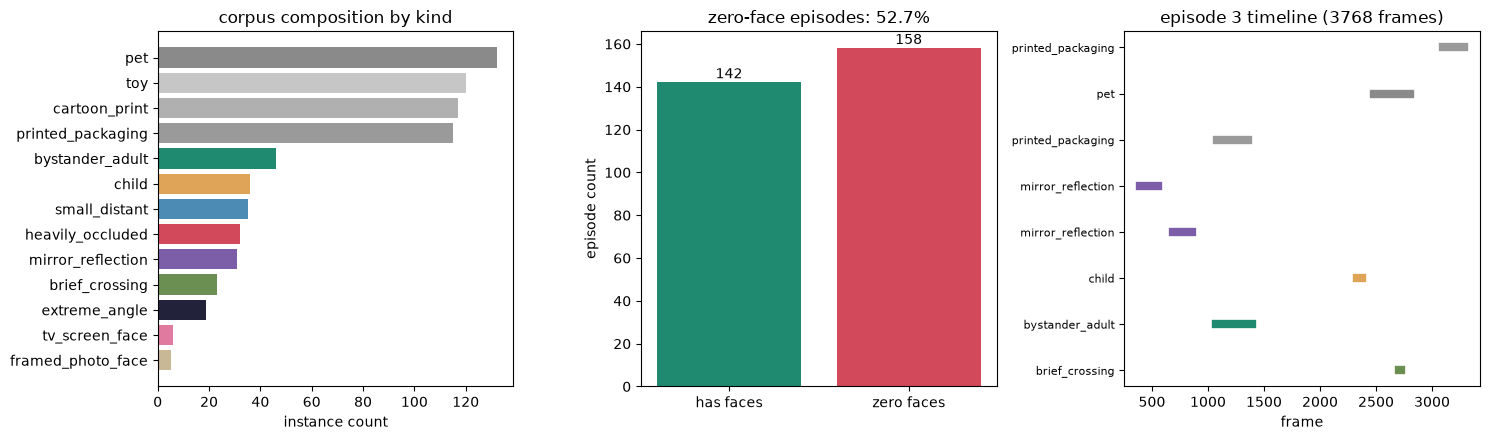

In [6]:
# VIZ
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

kind_counts = tracks["kind"].value_counts()
colors = [KIND_COLORS.get(k, "#999999") for k in kind_counts.index]
axes[0].barh(kind_counts.index[::-1], kind_counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("instance count")
axes[0].set_title("corpus composition by kind")

zero_counts = episodes["n_face_tracks"].eq(0).value_counts().reindex([False, True])
axes[1].bar(["has faces", "zero faces"], zero_counts.values,
            color=[PALETTE["teal"], PALETTE["coral"]])
for i, v in enumerate(zero_counts.values):
    axes[1].text(i, v + 2, str(int(v)), ha="center")
axes[1].set_ylabel("episode count")
axes[1].set_title(f"zero-face episodes: {zero_frac:.1%}")

example_ep = episodes.loc[episodes["n_face_tracks"] >= 2, "episode_id"].iloc[0]
ep_tracks = tracks[tracks["episode_id"] == example_ep].reset_index(drop=True)
for i, row in ep_tracks.iterrows():
    axes[2].plot([row["start_frame"], row["end_frame"]], [i, i], lw=6,
                 color=KIND_COLORS.get(row["kind"], "#999999"),
                 label=row["kind"] if row["kind"] not in ep_tracks["kind"].iloc[:i].values else None)
axes[2].set_yticks(range(len(ep_tracks)))
axes[2].set_yticklabels(ep_tracks["kind"], fontsize=8)
axes[2].set_xlabel("frame")
axes[2].set_title(f"episode {example_ep} timeline ({episodes.loc[episodes.episode_id==example_ep,'duration_frames'].iloc[0]} frames)")

fig.tight_layout()
plt.show()

## 2. Naive per-frame baseline

The naive baseline is what "run an off-the-shelf detector at a confidence threshold, per frame,
with no tracking" looks like: `stride=1`, `max_gap=0` (no bridging), `pad_before=pad_after=0` (no
temporal padding), `margin=0` (no box enlargement) in `run_pipeline` below.

Coverage/matching follows the box-wise idea in P2's localization loss (**Eq. 14**,
`[P2 Eq. 14, facered-q5]`): *"a relaxed loss controlling the proportion of uncovered ground-truth
boxes"* -- `1 - |{b_j in y : b_j subset of matched-and-margined prediction}| / |y|`. This notebook
uses the same "is the true box contained in the (margin-enlarged) predicted box" idea per
**frame**, then aggregates per **face instance** (track), because the client's unit is "recall...
per face instance", not per frame or per box -- P2 itself only evaluates per-image or per-object
static-image losses and does not define a video/track unit (`facered-q6`, `facered-q11`), so the
per-instance aggregation here is **derived here**.

**`false_blur_rate` / `precision`** (`false_blur_rate` = blur box-frames that do not overlap any
face-to-redact box, divided by all blur box-frames; `precision = 1 - false_blur_rate`) is also
**derived here** -- P2 explicitly does *not* control precision (`[P2 Sec. V-D, facered-q5]`):
*"our approach guarantees a large enough recall but only empirically limits false positives... In
fact, precision is a non-monotone function of its parameters, and monotonizing it using our
approach could lead to too large risks for a solution to exist."*

In [7]:
# REUSE
def run_pipeline(detections: pd.DataFrame, corpus: dict, pc: dict) -> pd.DataFrame:
    '''Blur boxes per frame given a pipeline config: score_thr, stride, max_gap (frames a track
    survives unmatched, bridged by linear interpolation), pad_before/pad_after (temporal padding),
    margin (multiplicative box margin, P2 Eq. 13 [facered-q5]: box grown by margin*w, margin*h on
    each side). Vectorised per (episode, source track) segment; no Python loop over frames.
    '''
    score_thr = pc.get("score_thr", 0.5)
    stride = int(pc.get("stride", 1))
    max_gap = int(pc.get("max_gap", 0))
    pad_before = int(pc.get("pad_before", 0))
    pad_after = int(pc.get("pad_after", 0))
    margin = float(pc.get("margin", 0.0))

    d = detections[detections["score"] >= score_thr]
    if stride > 1:
        d = d[d["frame"] % stride == 0]
    if len(d) == 0:
        return pd.DataFrame(columns=["episode_id", "frame", "x1", "y1", "x2", "y2", "track_key", "source_track_id"])

    d = d.sort_values(["episode_id", "source_track_id", "frame"])
    out = []
    for (ep_id, src), g in d.groupby(["episode_id", "source_track_id"], sort=False):
        frames = g["frame"].to_numpy()
        x1, y1, x2, y2 = (g[c].to_numpy() for c in ("x1", "y1", "x2", "y2"))
        gaps = np.diff(frames)
        breaks = np.where(gaps > max(1, max_gap + 1))[0] + 1
        seg_starts = np.concatenate(([0], breaks))
        seg_ends = np.concatenate((breaks, [len(frames)]))

        for s, e in zip(seg_starts, seg_ends):
            sf, sx1, sy1, sx2, sy2 = frames[s:e], x1[s:e], y1[s:e], x2[s:e], y2[s:e]
            if len(sf) == 1:
                ff, fx1, fy1, fx2, fy2 = sf, sx1, sy1, sx2, sy2
            else:
                ff = np.arange(sf[0], sf[-1] + 1)
                fx1, fy1, fx2, fy2 = (np.interp(ff, sf, v) for v in (sx1, sy1, sx2, sy2))

            if pad_before > 0 or pad_after > 0:
                lo = np.arange(ff[0] - pad_before, ff[0]) if pad_before > 0 else np.array([], int)
                hi = np.arange(ff[-1] + 1, ff[-1] + 1 + pad_after) if pad_after > 0 else np.array([], int)
                fx1 = np.concatenate([np.full(len(lo), fx1[0]), fx1, np.full(len(hi), fx1[-1])])
                fy1 = np.concatenate([np.full(len(lo), fy1[0]), fy1, np.full(len(hi), fy1[-1])])
                fx2 = np.concatenate([np.full(len(lo), fx2[0]), fx2, np.full(len(hi), fx2[-1])])
                fy2 = np.concatenate([np.full(len(lo), fy2[0]), fy2, np.full(len(hi), fy2[-1])])
                ff = np.concatenate([lo, ff, hi])

            w, h = fx2 - fx1, fy2 - fy1
            fx1, fx2 = fx1 - margin * w, fx2 + margin * w
            fy1, fy2 = fy1 - margin * h, fy2 + margin * h
            out.append(pd.DataFrame(dict(episode_id=ep_id, frame=ff, x1=fx1, y1=fy1, x2=fx2, y2=fy2,
                                          track_key=f"{ep_id}_{src}_{s}", source_track_id=src)))

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame(
        columns=["episode_id", "frame", "x1", "y1", "x2", "y2", "track_key", "source_track_id"])

In [8]:
# REUSE
def evaluate(corpus: dict, blur_boxes: pd.DataFrame, cover_rule: str = "contain",
             tolerance: float = 0.0) -> dict:
    '''Coverage rule 'contain': the (unmargined) ground-truth box must lie inside the blur box
    (margin already applied in run_pipeline), with an optional pixel tolerance. Returns a dict with
    per_instance table, instance_recall (strict), frame_recall, false_blur_rate, per_episode and
    per_kind aggregates. Designed for <= ~1-2s per call on the default corpus (grid-search speed).
    '''
    tracks, latent = corpus["tracks"], corpus["latent"]

    # ground-truth box table for ALL tracks, built once per latent store and cached on the corpus
    # dict (speed for grid search); filtered below by the CURRENT is_face_to_redact flags, so the
    # policy can be changed on `tracks` without invalidating the cache.
    cache = corpus.get("_gt_all")
    if cache is None or cache[0] != id(latent):
        gt_rows = []
        for tid, row in tracks.set_index("track_id").iterrows():
            L = latent[tid]
            gt_rows.append(pd.DataFrame(dict(
                track_id=tid, episode_id=row["episode_id"], kind=row["kind"], frame=L["frames"],
                gx1=L["cx"] - L["w"] / 2, gy1=L["cy"] - L["h"] / 2,
                gx2=L["cx"] + L["w"] / 2, gy2=L["cy"] + L["h"] / 2)))
        cache = (id(latent), pd.concat(gt_rows, ignore_index=True))
        corpus["_gt_all"] = cache
    face_ids = tracks.loc[tracks["is_face_to_redact"], "track_id"]
    gt = cache[1][cache[1]["track_id"].isin(face_ids)]

    if len(blur_boxes) and len(gt):
        merged = gt.merge(blur_boxes[["episode_id", "frame", "x1", "y1", "x2", "y2"]],
                           on=["episode_id", "frame"], how="left")
    else:
        merged = gt.copy()
        for col in ["x1", "y1", "x2", "y2"]:
            merged[col] = np.nan

    contained = ((merged["x1"] <= merged["gx1"] + tolerance) & (merged["y1"] <= merged["gy1"] + tolerance) &
                 (merged["x2"] >= merged["gx2"] - tolerance) & (merged["y2"] >= merged["gy2"] - tolerance))
    merged["covered"] = contained.fillna(False)
    per_frame_cov = merged.groupby(["track_id", "episode_id", "frame"], as_index=False)["covered"].max()

    per_instance = per_frame_cov.groupby(["track_id", "episode_id"]).agg(
        n_visible_frames=("frame", "count"),
        n_uncovered_frames=("covered", lambda s: int((~s).sum()))).reset_index()
    per_instance["instance_missed"] = per_instance["n_uncovered_frames"] > 0
    per_instance["kind"] = per_instance["track_id"].map(tracks.set_index("track_id")["kind"])

    n_instances = len(per_instance)
    instance_recall = float((~per_instance["instance_missed"]).mean()) if n_instances else float("nan")
    n_face_frames = len(per_frame_cov)
    frame_recall = (per_frame_cov["covered"].sum() / n_face_frames) if n_face_frames else float("nan")

    # false blur is decided PER BLUR BOX-FRAME: false = the box overlaps no face-to-redact GT box in
    # its (episode, frame). `blur_is_false` is aligned with blur_boxes.reset_index(drop=True).
    n_blur_boxframes = len(blur_boxes)
    blur_is_false = np.ones(n_blur_boxframes, dtype=bool)
    if n_blur_boxframes and len(gt):
        bb = blur_boxes[["episode_id", "frame", "x1", "y1", "x2", "y2"]].reset_index(drop=True)
        bb["_bid"] = np.arange(n_blur_boxframes)
        bcheck = bb.merge(gt[["episode_id", "frame", "gx1", "gy1", "gx2", "gy2"]],
                           on=["episode_id", "frame"], how="left")
        overlaps = ~((bcheck["gx2"].isna()) | (bcheck["x2"] < bcheck["gx1"]) | (bcheck["x1"] > bcheck["gx2"]) |
                     (bcheck["y2"] < bcheck["gy1"]) | (bcheck["y1"] > bcheck["gy2"]))
        blur_is_false[bcheck.loc[overlaps, "_bid"].unique()] = False
    false_blur_rate = float(blur_is_false.mean()) if n_blur_boxframes else float("nan")
    precision = 1 - false_blur_rate if false_blur_rate == false_blur_rate else float("nan")

    per_episode = per_instance.groupby("episode_id").agg(
        n_instances=("track_id", "count"), n_missed=("instance_missed", "sum")).reset_index()
    per_kind = per_instance.groupby("kind").agg(
        n_instances=("track_id", "count"),
        instance_recall=("instance_missed", lambda s: float((~s).mean()))).reset_index()

    return dict(per_instance=per_instance, instance_recall=instance_recall, frame_recall=frame_recall,
                false_blur_rate=false_blur_rate, precision=precision, per_episode=per_episode,
                per_kind=per_kind, n_instances=n_instances, n_face_frames=n_face_frames,
                n_blur_boxframes=n_blur_boxframes, blur_is_false=blur_is_false)

In [9]:
# REUSE
import dataclasses as _dc

FALSE_BLUR_CATEGORIES = ["pet", "toy", "cartoon_print", "printed_packaging", "tv_screen_face",
                         "framed_photo_face", "padding_outside_track", "other"]


def apply_policy(corpus: dict, redact_screen_and_photo_faces: bool) -> dict:
    '''Copy of `corpus` whose tracks table has is_face_to_redact re-derived for the screen/photo
    policy. Everything else (latent truth, episodes) is shared, so the SAME detections can be
    scored under either policy. Only screen/photo tracks change; all other flags are untouched.'''
    tracks = corpus["tracks"].copy()
    tracks["is_face_to_redact"] = np.where(tracks["is_screen_or_photo"], bool(redact_screen_and_photo_faces),
                                            tracks["is_face_to_redact"]).astype(bool)
    out = dict(corpus)
    out["tracks"] = tracks
    out["cfg"] = _dc.replace(corpus["cfg"], policy_redact_screen_and_photo_faces=bool(redact_screen_and_photo_faces))
    return out


def false_blur_decomposition(corpus: dict, blur_boxes: pd.DataFrame, res: dict = None) -> pd.DataFrame:
    '''Attributes every false-blur box-frame (a blur box overlapping no face-to-redact GT box, as in
    evaluate) to a cause, by the detection track that produced it (blur_boxes.source_track_id):
      pet / toy / cartoon_print / printed_packaging : detector clutter from that distractor kind
      tv_screen_face / framed_photo_face            : face-like images NOT to be redacted under the policy
      padding_outside_track : a box from a real face-to-redact track, on a frame OUTSIDE that
                              track's true extent (temporal padding; counting it as false blur is a
                              DEFINITION made here)
      other : pure background clutter (source -1) and real-track boxes that miss the GT box inside the track
    Returns a DataFrame(category, n_false_boxframes, share); shares sum to 1.'''
    if res is None:
        res = evaluate(corpus, blur_boxes)
    bb = blur_boxes.reset_index(drop=True)
    fb = bb[res["blur_is_false"]]
    tr = corpus["tracks"].set_index("track_id")
    src = fb["source_track_id"].to_numpy()
    kind = pd.Series(src).map(tr["kind"]).to_numpy(dtype=object)
    redact = pd.Series(src).map(tr["is_face_to_redact"]).to_numpy(dtype=object)
    start = pd.Series(src).map(tr["start_frame"]).to_numpy(dtype=float)
    end = pd.Series(src).map(tr["end_frame"]).to_numpy(dtype=float)
    fr = fb["frame"].to_numpy()
    cat = np.full(len(fb), "other", dtype=object)
    not_redact = (redact == False) & (src >= 0)  # noqa: E712
    cat[not_redact] = kind[not_redact]
    is_redact_src = (redact == True) & (src >= 0)  # noqa: E712
    outside = is_redact_src & ((fr < start) | (fr > end))
    cat[outside] = "padding_outside_track"
    counts = pd.Series(cat).value_counts().reindex(FALSE_BLUR_CATEGORIES).fillna(0).astype(int)
    total = int(counts.sum())
    return pd.DataFrame(dict(category=counts.index, n_false_boxframes=counts.values,
                             share=(counts.values / total) if total else np.zeros(len(counts))))

In [10]:
NAIVE_PC = dict(score_thr=0.5, stride=1, max_gap=0, pad_before=0, pad_after=0, margin=0.0)
t0 = time.time()
naive_blur = run_pipeline(DETECTIONS, CORPUS, NAIVE_PC)
naive_res = evaluate(CORPUS, naive_blur)
t_naive = time.time() - t0

print(f"run_pipeline + evaluate (naive): {t_naive:.3f}s for {naive_res['n_instances']} instances, "
      f"{len(naive_blur)} blur box-frames")
print()
ir = naive_res["instance_recall"]
print(f"CHECK 2.1: strict instance recall >= 0.99 -> {ir:.3f} -> requirement met? "
      f"{'YES' if ir >= 0.99 else 'NO'} (expected NO: naive baseline should fail the strict bar)")
print(f"CHECK 2.2: frame recall (informational, not the client's metric) -> {naive_res['frame_recall']:.3f}")
prec = naive_res["precision"]
print(f"CHECK 2.3: precision >= 0.95 -> {prec:.3f} -> requirement met? {'YES' if prec >= 0.95 else 'NO'}")
worst_kinds = naive_res["per_kind"].sort_values("instance_recall").head(3)
print("CHECK 2.4: per-kind instance recall, lowest three kinds:")
print(worst_kinds.to_string(index=False))

run_pipeline + evaluate (naive): 2.036s for 222 instances, 42982 blur box-frames

CHECK 2.1: strict instance recall >= 0.99 -> 0.113 -> requirement met? NO (expected NO: naive baseline should fail the strict bar)
CHECK 2.2: frame recall (informational, not the client's metric) -> 0.905
CHECK 2.3: precision >= 0.95 -> 0.781 -> requirement met? NO
CHECK 2.4: per-kind instance recall, lowest three kinds:
            kind  n_instances  instance_recall
           child           36          0.00000
   small_distant           35          0.00000
heavily_occluded           32          0.03125


#### How to read this chart

Left: strict instance recall by kind, naive baseline, with the client's 0.99 bar as a dashed
line -- every kind falls far short. Children, small/distant faces, heavily occluded faces and
mirror reflections score lowest (near 0); bystanders and brief crossings score highest but still
well under the bar, because *any* single uncovered frame fails the whole instance. Right: as the
score threshold sweeps from permissive to strict, instance recall (solid) and frame recall (dashed)
fall while precision (dotted) rises at first and then dips at very high thresholds -- precision is
not monotone in the threshold, echoing P2's remark (`[P2 Sec. V-D, facered-q5]`). Instance recall
never comes close to 0.99 at any threshold (its maximum is at the most permissive threshold, where
precision is lowest), so there is no threshold on this baseline where both targets hold -- the
"off-the-shelf hits a wall" finding this notebook is built to make checkable.

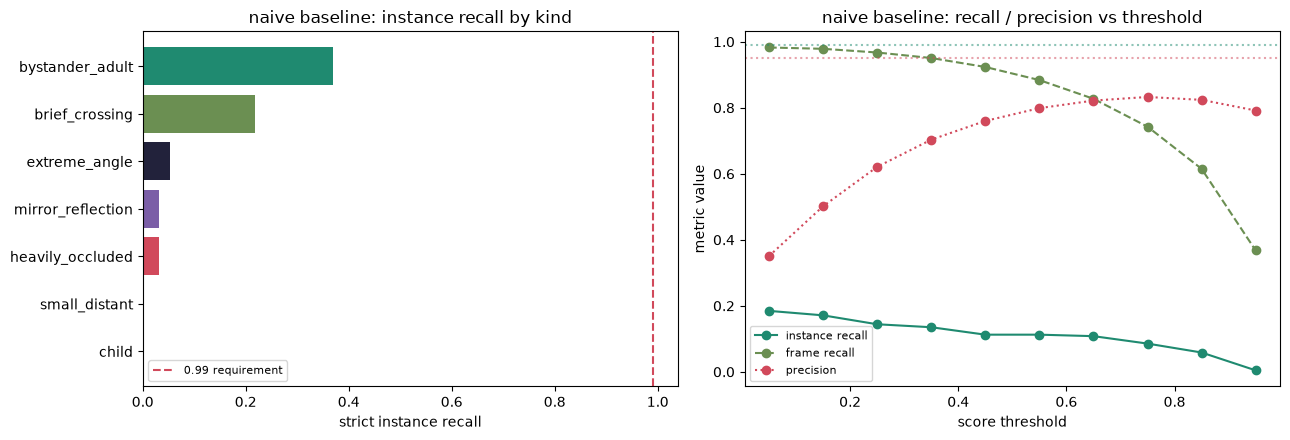

In [11]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

pk = naive_res["per_kind"].sort_values("instance_recall")
colors = [KIND_COLORS.get(k, "#999999") for k in pk["kind"]]
axes[0].barh(pk["kind"], pk["instance_recall"], color=colors)
axes[0].axvline(0.99, color=PALETTE["coral"], linestyle="--", label="0.99 requirement")
axes[0].set_xlabel("strict instance recall")
axes[0].set_title("naive baseline: instance recall by kind")
axes[0].legend(fontsize=8)

thrs = np.linspace(0.05, 0.95, 10)
curve = []
for thr in thrs:
    pc = dict(NAIVE_PC, score_thr=thr)
    bb = run_pipeline(DETECTIONS, CORPUS, pc)
    r = evaluate(CORPUS, bb)
    curve.append((thr, r["instance_recall"], r["frame_recall"], r["precision"]))
curve = pd.DataFrame(curve, columns=["thr", "instance_recall", "frame_recall", "precision"])

axes[1].plot(curve["thr"], curve["instance_recall"], "-o", color=PALETTE["teal"], label="instance recall")
axes[1].plot(curve["thr"], curve["frame_recall"], "--o", color=PALETTE["moss"], label="frame recall")
axes[1].plot(curve["thr"], curve["precision"], ":o", color=PALETTE["coral"], label="precision")
axes[1].axhline(0.99, color=PALETTE["teal"], linestyle=":", alpha=0.5)
axes[1].axhline(0.95, color=PALETTE["coral"], linestyle=":", alpha=0.5)
axes[1].set_xlabel("score threshold")
axes[1].set_ylabel("metric value")
axes[1].set_title("naive baseline: recall / precision vs threshold")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 3. Tracking + temporal padding + multiplicative margin

Everything in this section's *mechanism* -- bridging a track across a score-threshold gap up to
`max_gap` frames, adding `pad_before`/`pad_after` frames of padding around a track, and running the
detector only every `stride`-th frame -- is **derived here**: none of the three papers models
video, tracking, or temporal padding (`[facered-q6, facered-q12]`: *"None of the papers provide
guarantees under temporal frame-to-frame dependence in video"*). The idea that the client's own
language points to -- *"a face detected in frame 100 and missed in 101-108 is still a privacy
failure"* -- is exactly what `max_gap` bridging and padding are built to fix.

The **box margin** mechanism is not derived here: it reuses P2's multiplicative margin
(**Eq. 13**, `[P2 Eq. 13, facered-q5]`): *"Scales the parameter lambda_loc by the width w_hat_k and
height h_hat_k of the predicted box, ensuring adaptivity to object dimensions"* -- growing the box
by `margin * w` / `margin * h` on each side, as opposed to a fixed pixel margin that would
disproportionately affect small/distant faces.

This section runs a small grid over `(score_thr, max_gap, pad, margin)` and reports:
whether tracking+padding improves strict instance recall over `## 2` at the same threshold; the
best precision achieved among configs with instance recall >= 0.80; and whether **any** tried
config reaches both targets on the full corpus. That last answer is a **point estimate on
synthetic data**, stated as such -- it is not a guarantee, and Notebook 3's job is to certify (or
refute) a configuration with a stated probability.

In [12]:
# The same detections are also scored under the OTHER screen/photo policy (see 3(b) below): the
# policy only changes which ground-truth tracks count as faces to redact, not the detector output.
CORPUS_PT = apply_policy(CORPUS, True)
GRID = []
for thr in [0.5, 0.6, 0.7, 0.8]:
    for gap in [0, 5, 15]:
        for pad in [0, 3, 8]:
            for margin in [0.0, 0.10, 0.25]:
                pc = dict(score_thr=thr, stride=1, max_gap=gap, pad_before=pad, pad_after=pad, margin=margin)
                bb = run_pipeline(DETECTIONS, CORPUS, pc)
                r = evaluate(CORPUS, bb)
                rt = evaluate(CORPUS_PT, bb)
                GRID.append(dict(score_thr=thr, max_gap=gap, pad=pad, margin=margin,
                                  instance_recall=r["instance_recall"], frame_recall=r["frame_recall"],
                                  precision=r["precision"], false_blur_rate=r["false_blur_rate"],
                                  instance_recall_pT=rt["instance_recall"], precision_pT=rt["precision"]))
GRID = pd.DataFrame(GRID)
print(f"grid: {len(GRID)} configurations")

# same threshold as the naive baseline (0.5), best tracked config vs. naive
same_thr = GRID[GRID["score_thr"] == 0.5]
best_tracked_at_thr = same_thr.loc[same_thr["instance_recall"].idxmax()]
print()
print(f"CHECK 3.1: best tracking+padding+margin instance recall at score_thr=0.5 "
      f"({best_tracked_at_thr['instance_recall']:.3f}) > naive instance recall ({ir:.3f}) -> "
      f"{'PASS' if best_tracked_at_thr['instance_recall'] > ir else 'FAIL'}")
print(f"  config: max_gap={int(best_tracked_at_thr.max_gap)} pad={int(best_tracked_at_thr.pad)} "
      f"margin={best_tracked_at_thr.margin}")

both_targets = GRID[(GRID["instance_recall"] >= 0.99) & (GRID["precision"] >= 0.95)]
print()
print(f"CHECK 3.2: any grid config reaches instance_recall >= 0.99 AND precision >= 0.95 "
      f"on the FULL corpus (point estimate) -> {'YES' if len(both_targets) else 'NO'} "
      f"({len(both_targets)}/{len(GRID)} configs)")
print("  This is a POINT ESTIMATE on synthetic data, not a guarantee -- Notebook 3 certifies "
      "(or refutes) a configuration with a stated 1-delta probability.")

best_recall_ge_80 = GRID[GRID["instance_recall"] >= 0.80].sort_values("precision", ascending=False)
print()
print("Best-precision config among instance_recall >= 0.80:")
print(best_recall_ge_80.head(1).to_string(index=False))

t0 = time.time()
_ = evaluate(CORPUS, run_pipeline(DETECTIONS, CORPUS, dict(score_thr=0.6, stride=1, max_gap=10,
                                                            pad_before=5, pad_after=5, margin=0.15)))
t_one_cfg = time.time() - t0
print(f"\nCHECK 3.3: run_pipeline + evaluate per configuration <= 2s -> {t_one_cfg:.3f}s -> "
      f"{'PASS' if t_one_cfg <= 2.0 else 'FAIL'}")

grid: 108 configurations

CHECK 3.1: best tracking+padding+margin instance recall at score_thr=0.5 (0.959) > naive instance recall (0.113) -> PASS
  config: max_gap=0 pad=8 margin=0.25

CHECK 3.2: any grid config reaches instance_recall >= 0.99 AND precision >= 0.95 on the FULL corpus (point estimate) -> NO (0/108 configs)
  This is a POINT ESTIMATE on synthetic data, not a guarantee -- Notebook 3 certifies (or refutes) a configuration with a stated 1-delta probability.

Best-precision config among instance_recall >= 0.80:
 score_thr  max_gap  pad  margin  instance_recall  frame_recall  precision  false_blur_rate  instance_recall_pT  precision_pT
       0.5       15    0     0.1         0.815315      0.991968   0.732359         0.267641            0.824034      0.824159



CHECK 3.3: run_pipeline + evaluate per configuration <= 2s -> 0.608s -> PASS


In [13]:
# Stride's effect on the recall/precision trade-off (the cost knob: running the detector every
# s-th frame is s times cheaper, at the cost of relying more on interpolation/holding between
# detections). Dollar cost is not computed here -- it needs measured throughput from ## 4;
# processing_cost() is applied to these same configs later, once real fps numbers exist.
STRIDE_ROWS = []
for stride in [1, 2, 4, 8]:
    pc = dict(score_thr=0.6, stride=stride, max_gap=15, pad_before=5, pad_after=5, margin=0.15)
    r = evaluate(CORPUS, run_pipeline(DETECTIONS, CORPUS, pc))
    STRIDE_ROWS.append(dict(stride=stride, instance_recall=r["instance_recall"],
                             precision=r["precision"]))
STRIDE_DF = pd.DataFrame(STRIDE_ROWS)
print("stride sweep (score_thr=0.6, max_gap=15, pad=5, margin=0.15):")
print(STRIDE_DF.to_string(index=False))
print("\nCHECK 3.4: instance recall is non-increasing as stride grows (fewer detector calls should "
      f"not help recall) -> {'PASS' if STRIDE_DF['instance_recall'].is_monotonic_decreasing or STRIDE_DF['instance_recall'].nunique()==1 else 'FAIL (see note)'}")

stride sweep (score_thr=0.6, max_gap=15, pad=5, margin=0.15):
 stride  instance_recall  precision
      1         0.846847   0.685800
      2         0.765766   0.712022
      4         0.617117   0.747088
      8         0.256757   0.790633

CHECK 3.4: instance recall is non-increasing as stride grows (fewer detector calls should not help recall) -> PASS


#### How to read this chart

Left: every grid configuration plotted as instance recall vs. precision, coloured by padding
(darker = more padding) with marker shape by margin; the dashed lines mark the 0.99 / 0.95
requirement box -- the top-right corner. No point sits in that corner: this is the trade-off
frontier the client is up against, and the honest answer to "does any config on synthetic data
reach both targets" is visible directly, not just printed. Right: a frame-strip illustration of
one real track from this corpus -- raw per-frame detections (naive, top row) vs. the same track
after `max_gap` bridging and padding (bottom row) -- showing concretely what "bridging a gap"
does to the covered-frame set for one instance.

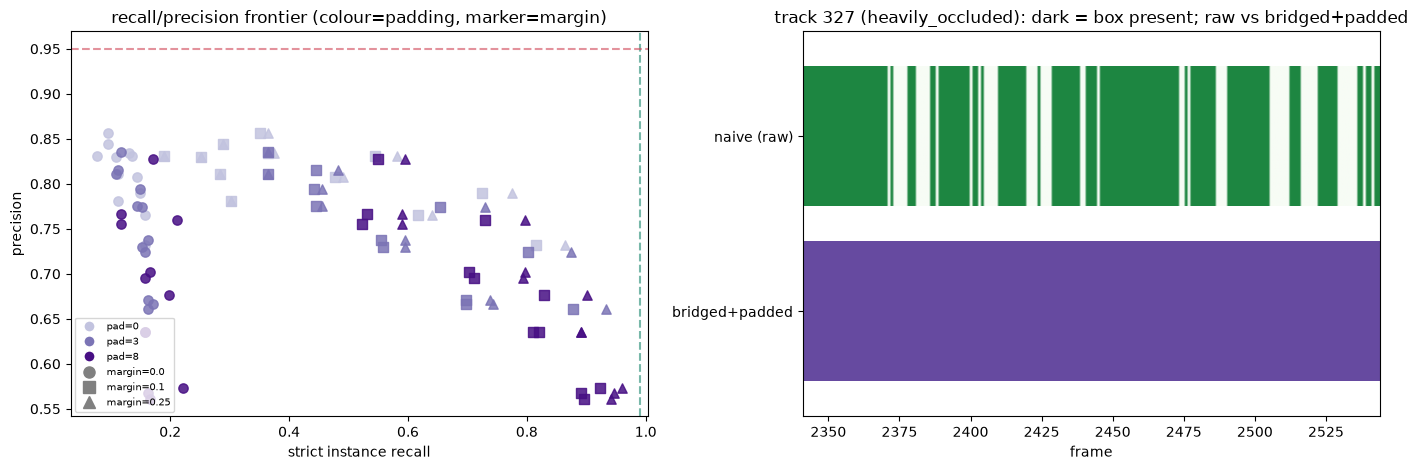

In [14]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

pad_vals = sorted(GRID["pad"].unique())
pad_shades = {p: c for p, c in zip(pad_vals, plt.cm.Purples(np.linspace(0.35, 0.95, len(pad_vals))))}
margin_markers = {0.0: "o", 0.10: "s", 0.25: "^"}
for pad in pad_vals:
    for margin in sorted(GRID["margin"].unique()):
        sub = GRID[(GRID["pad"] == pad) & (GRID["margin"] == margin)]
        axes[0].scatter(sub["instance_recall"], sub["precision"], color=pad_shades[pad],
                         marker=margin_markers[margin], s=45, alpha=0.85,
                         label=f"pad={pad}, margin={margin}" if False else None)
axes[0].axvline(0.99, color=PALETTE["teal"], linestyle="--", alpha=0.6)
axes[0].axhline(0.95, color=PALETTE["coral"], linestyle="--", alpha=0.6)
axes[0].set_xlabel("strict instance recall")
axes[0].set_ylabel("precision")
axes[0].set_title("recall/precision frontier (colour=padding, marker=margin)")
# small legend proxies
from matplotlib.lines import Line2D
proxies = [Line2D([0], [0], marker="o", color="w", markerfacecolor=pad_shades[p], markersize=8, label=f"pad={p}")
           for p in pad_vals]
proxies += [Line2D([0], [0], marker=m, color="gray", linestyle="", markersize=8, label=f"margin={mv}")
            for mv, m in margin_markers.items()]
axes[0].legend(handles=proxies, fontsize=7, loc="lower left")

# pick a real face track that has at least one bridgeable gap in its raw >=0.6-score detections
bridged_pc = dict(score_thr=0.6, stride=1, max_gap=15, pad_before=5, pad_after=5, margin=0.0)
example_track, best_gaps = None, -1
for _, cand in tracks[(tracks["is_real_face"]) & (tracks["end_frame"] - tracks["start_frame"] > 40)].iterrows():
    fr_c = DETECTIONS.loc[(DETECTIONS["source_track_id"] == cand["track_id"]) & (DETECTIONS["score"] >= 0.6), "frame"]
    n_missing = int(cand["end_frame"] - cand["start_frame"] + 1 - fr_c.nunique())
    if 3 <= n_missing <= 60 and n_missing > best_gaps:
        example_track, best_gaps = cand, n_missing
if example_track is None:
    example_track = tracks[(tracks["is_real_face"]) & (tracks["end_frame"] - tracks["start_frame"] > 40)].iloc[0]
tid = int(example_track["track_id"])
raw = DETECTIONS[(DETECTIONS["source_track_id"] == tid) & (DETECTIONS["score"] >= 0.6)].sort_values("frame")
bridged_bb = run_pipeline(DETECTIONS[DETECTIONS["source_track_id"] == tid], CORPUS, bridged_pc)
lo, hi = int(example_track["start_frame"]), int(example_track["end_frame"])
frame_axis = np.arange(lo, hi + 1)
raw_present = np.isin(frame_axis, raw["frame"].to_numpy())
bridged_present = np.isin(frame_axis, bridged_bb["frame"].to_numpy())
axes[1].imshow(raw_present[None, :].astype(float), aspect="auto", cmap="Greens", vmin=0, vmax=1.3,
               extent=[lo, hi, 0.6, 1.4])
axes[1].imshow(bridged_present[None, :].astype(float), aspect="auto", cmap="Purples", vmin=0, vmax=1.3,
               extent=[lo, hi, -0.4, 0.4])
axes[1].set_ylim(-0.6, 1.6)
axes[1].set_yticks([1.0, 0.0])
axes[1].set_yticklabels(["naive (raw)", "bridged+padded"])
axes[1].set_xlabel("frame")
axes[1].set_title(f"track {tid} ({example_track['kind']}): dark = box present; raw vs bridged+padded")

fig.tight_layout()
plt.show()

### 3(b) The screen/photo policy changes the numbers (same detections, both policies)

`SimConfig.policy_redact_screen_and_photo_faces` (default `False`) only decides which ground-truth
tracks count as faces to redact -- it does not change what the detector outputs, and a detector
cannot tell a TV face from a bystander. So the honest comparison scores the **same detections** and
the **same pipeline configurations** under both policies. Three configurations are compared, all
chosen under the default policy: (a) the naive baseline, (b) the best-precision configuration among
those with instance recall >= 0.80, (c) the best-recall configuration at `score_thr=0.5`. The
policy comparison itself is **derived here** (it is a definition, not a paper result).

The comparison scores the corpus with `apply_policy(...)` (an override of `is_face_to_redact` on
the existing tables). A CHECK verifies that this is legitimate: regenerating the corpus with the
policy flag set to `True` and the same seed gives tracks and latent arrays identical to the
original apart from `is_face_to_redact`, and its `tracks` table equals the override's.

In [15]:
BEST_PREC_PC = dict(score_thr=float(best_recall_ge_80.iloc[0]["score_thr"]),
                    max_gap=int(best_recall_ge_80.iloc[0]["max_gap"]),
                    pad_before=int(best_recall_ge_80.iloc[0]["pad"]), pad_after=int(best_recall_ge_80.iloc[0]["pad"]),
                    margin=float(best_recall_ge_80.iloc[0]["margin"]), stride=1)
BEST_REC_PC = dict(score_thr=0.5, stride=1, max_gap=int(best_tracked_at_thr.max_gap),
                   pad_before=int(best_tracked_at_thr.pad), pad_after=int(best_tracked_at_thr.pad),
                   margin=float(best_tracked_at_thr.margin))
POLICY_CONFIGS = {"naive": NAIVE_PC, "best precision @ recall>=0.80": BEST_PREC_PC,
                  "best recall @ thr=0.5": BEST_REC_PC}

# provenance of the override: regenerate with the policy flag True, same seed
CORPUS_REGEN_PT = generate_corpus(SimConfig(seed=SEED, policy_redact_screen_and_photo_faces=True))
other_cols = [c for c in tracks.columns if c != "is_face_to_redact"]
LATENT_KEYS = ["frames", "cx", "cy", "w", "h", "occlusion", "blur", "angle", "ar1_noise"]
same_tracks = CORPUS_REGEN_PT["tracks"][other_cols].equals(CORPUS["tracks"][other_cols])
same_latent = (set(CORPUS_REGEN_PT["latent"]) == set(CORPUS["latent"]) and
               all(np.array_equal(CORPUS_REGEN_PT["latent"][t][k], CORPUS["latent"][t][k])
                   for t in CORPUS["latent"] for k in LATENT_KEYS))
override_matches = CORPUS_REGEN_PT["tracks"].equals(CORPUS_PT["tracks"])
n_screen_photo = int(tracks["is_screen_or_photo"].sum())
print(f"CHECK 3.5: regenerated policy=True corpus has identical tracks (apart from is_face_to_redact) and "
      f"identical latent arrays, and equals the override -> tracks={same_tracks}, latent={same_latent}, "
      f"override={override_matches} -> {'PASS' if (same_tracks and same_latent and override_matches) else 'FAIL'}")

POLICY_ROWS, POLICY_BLUR = [], {}
for name, pc in POLICY_CONFIGS.items():
    bb = run_pipeline(DETECTIONS, CORPUS, pc)
    POLICY_BLUR[name] = bb
    for pol_name, corp in [("screen/photo NOT redacted (default)", CORPUS), ("screen/photo redacted", CORPUS_PT)]:
        r = evaluate(corp, bb)
        POLICY_ROWS.append(dict(config=name, policy=pol_name, n_instances=r["n_instances"],
                                 instance_recall=r["instance_recall"], frame_recall=r["frame_recall"],
                                 precision=r["precision"]))
POLICY_DF = pd.DataFrame(POLICY_ROWS)
print()
print(POLICY_DF.round(3).to_string(index=False))

print()
ok_n, ok_p = True, True
for name in POLICY_CONFIGS:
    sub = POLICY_DF[POLICY_DF["config"] == name].set_index("policy")
    d_n = int(sub.loc["screen/photo redacted", "n_instances"] - sub.loc["screen/photo NOT redacted (default)", "n_instances"])
    ok_n &= (d_n == n_screen_photo)
    ok_p &= bool(sub.loc["screen/photo redacted", "precision"] >= sub.loc["screen/photo NOT redacted (default)", "precision"])
print(f"CHECK 3.6: switching the policy to 'redact' adds exactly the {n_screen_photo} screen/photo instances "
      f"to the evaluated set, for every config -> {'PASS' if ok_n else 'FAIL'}")
print(f"CHECK 3.7: precision under 'redact' >= precision under 'not redacted' for every config "
      f"(those detections stop being false blurs) -> {'PASS' if ok_p else 'FAIL'}")
both_pT = GRID[(GRID["instance_recall_pT"] >= 0.99) & (GRID["precision_pT"] >= 0.95)]
print(f"CHECK 3.8: any grid config reaches instance_recall >= 0.99 AND precision >= 0.95 under policy "
      f"'redact' (point estimate, synthetic) -> {'YES' if len(both_pT) else 'NO'} ({len(both_pT)}/{len(GRID)} configs)")
gt80 = GRID[GRID["instance_recall_pT"] >= 0.80].sort_values("precision_pT", ascending=False)
if len(gt80):
    print(f"  best precision under 'redact' among configs with instance recall >= 0.80: "
          f"{gt80.iloc[0]['precision_pT']:.3f} (instance recall {gt80.iloc[0]['instance_recall_pT']:.3f})")

CHECK 3.5: regenerated policy=True corpus has identical tracks (apart from is_face_to_redact) and identical latent arrays, and equals the override -> tracks=True, latent=True, override=True -> PASS



                       config                              policy  n_instances  instance_recall  frame_recall  precision
                        naive screen/photo NOT redacted (default)          222            0.113         0.905      0.781
                        naive               screen/photo redacted          233            0.133         0.916      0.886
best precision @ recall>=0.80 screen/photo NOT redacted (default)          222            0.815         0.992      0.732
best precision @ recall>=0.80               screen/photo redacted          233            0.824         0.993      0.824
        best recall @ thr=0.5 screen/photo NOT redacted (default)          222            0.959         0.999      0.573
        best recall @ thr=0.5               screen/photo redacted          233            0.961         0.999      0.623

CHECK 3.6: switching the policy to 'redact' adds exactly the 11 screen/photo instances to the evaluated set, for every config -> PASS
CHECK 3.7: precis

#### How to read this chart

Two panels, one bar pair per pipeline configuration: strict instance recall (left) and precision
(right) when TV/framed-photo faces are **not** redacted (slate, the default) vs. **redacted** (rose),
with the 0.99 / 0.95 requirement lines dashed. Precision rises under "redact" because confident
detections of screen/photo faces stop being false blurs; instance recall moves because those
instances now count as faces that must be covered. The gap between the two colours is the size of
the definitional choice -- separate from anything the detector or the tracker does.

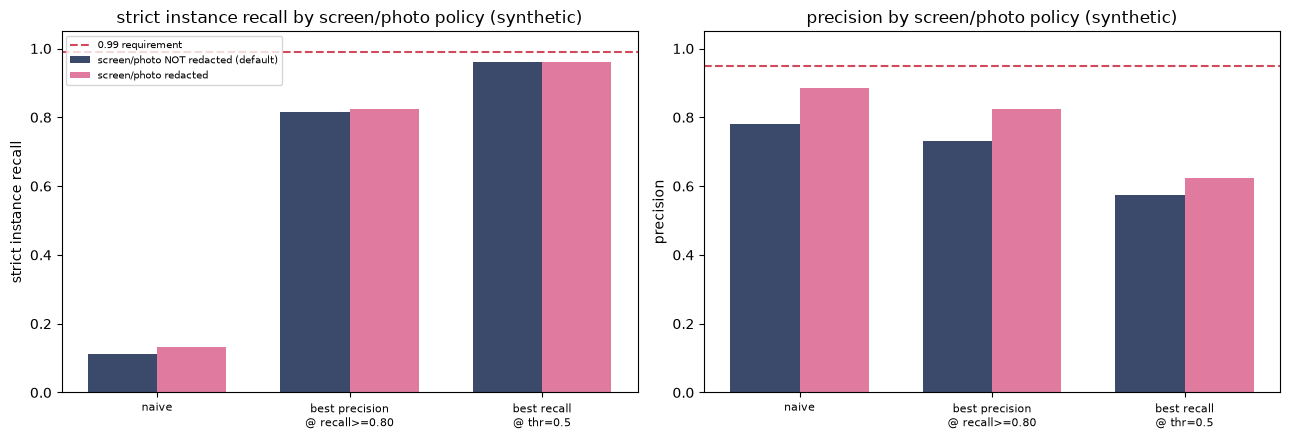

In [16]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
cfg_names = list(POLICY_CONFIGS)
xs = np.arange(len(cfg_names)); w = 0.36
for ax, metric, line, title in [(axes[0], "instance_recall", 0.99, "strict instance recall"),
                                 (axes[1], "precision", 0.95, "precision")]:
    v_no = [POLICY_DF[(POLICY_DF["config"] == c) & (POLICY_DF["policy"].str.contains("NOT"))][metric].iloc[0] for c in cfg_names]
    v_yes = [POLICY_DF[(POLICY_DF["config"] == c) & (~POLICY_DF["policy"].str.contains("NOT"))][metric].iloc[0] for c in cfg_names]
    ax.bar(xs - w / 2, v_no, w, color=PALETTE["slate"], label="screen/photo NOT redacted (default)")
    ax.bar(xs + w / 2, v_yes, w, color=PALETTE["rose"], label="screen/photo redacted")
    ax.axhline(line, color=PALETTE["coral"], linestyle="--", label=f"{line} requirement")
    ax.set_xticks(xs); ax.set_xticklabels([c.replace(" @ ", "\n@ ") for c in cfg_names], fontsize=8)
    ax.set_ylabel(title); ax.set_ylim(0, 1.05)
    ax.set_title(f"{title} by screen/photo policy (synthetic)")
axes[0].legend(fontsize=7, loc="upper left")
fig.tight_layout()
plt.show()

### 3(c) Where does precision go? A decomposition of false-blur box-frames

At the best-recall configuration precision is well below 0.95 (about 0.57 in the Results summary) and
no grid configuration meets both bars.
This decomposition says which part of the false blurring is (i) detector clutter from a distractor
kind, (ii) a definitional choice (TV/photo faces under the default policy), (iii) the cost of
temporal padding, or (iv) other. Every false-blur box-frame -- a blur box that overlaps no
face-to-redact ground-truth box in its frame, exactly as in `evaluate` -- is attributed to the
detection track that produced it (`source_track_id`).

**Definitions made here (derived here):** (iii) "padding" means a box from a real face-to-redact
track on a frame *outside* that track's true extent, i.e. bridging/padding frames with no GT face
present; **counting those frames as false blur is a definition made here**, not something the
papers prescribe (padding is a deliberate privacy margin, and one could argue it should not count
against precision). Padding applied to a *clutter* track is attributed to that clutter kind (the
cause is the false detection; padding only lengthens it), so the "padding" category alone
understates padding's total contribution; the cell below also reports, by difference against the
naive configuration (same threshold, no bridging or padding), how many extra clutter box-frames
the padded configuration draws. "Other" = pure background clutter (no track) plus real-track boxes
that miss the GT box inside the track's extent.

In [17]:
DECOMP_SETS = [("naive, policy: NOT redacted", NAIVE_PC, CORPUS),
               ("best recall, policy: NOT redacted", BEST_REC_PC, CORPUS),
               ("best recall, policy: redacted", BEST_REC_PC, CORPUS_PT)]
DECOMP, DECOMP_TOTALS = {}, {}
for label, pc, corp in DECOMP_SETS:
    bb = POLICY_BLUR["naive"] if pc is NAIVE_PC else POLICY_BLUR["best recall @ thr=0.5"]
    res = evaluate(corp, bb)
    dec = false_blur_decomposition(corp, bb, res)
    DECOMP[label] = dec
    DECOMP_TOTALS[label] = dict(n_blur=int(res["n_blur_boxframes"]), n_false=int(res["blur_is_false"].sum()),
                                 precision=res["precision"])
    print(f"--- {label}: {DECOMP_TOTALS[label]['n_false']} false of {DECOMP_TOTALS[label]['n_blur']} "
          f"blur box-frames (precision {res['precision']:.3f})")
    print(dec.assign(share=dec["share"].round(3)).to_string(index=False))

print()
for label in DECOMP:
    s = DECOMP[label]["share"].sum()
    print(f"CHECK 3.9 [{label}]: decomposition shares sum to 1 (+-1e-9) -> {s:.12f} -> "
          f"{'PASS' if abs(s - 1.0) <= 1e-9 else 'FAIL'}")
for label in DECOMP:
    n_dec = int(DECOMP[label]["n_false_boxframes"].sum())
    print(f"CHECK 3.10 [{label}]: decomposed count equals evaluate()'s false box-frame count "
          f"({n_dec} vs {DECOMP_TOTALS[label]['n_false']}) -> "
          f"{'PASS' if n_dec == DECOMP_TOTALS[label]['n_false'] else 'FAIL'}")
pad_naive = float(DECOMP["naive, policy: NOT redacted"].set_index("category").loc["padding_outside_track", "share"])
print(f"CHECK 3.11: naive config uses no padding, so its padding share must be 0 -> {pad_naive:.3f} -> "
      f"{'PASS' if pad_naive == 0 else 'FAIL'}")
sp_true = float(DECOMP["best recall, policy: redacted"].set_index("category").loc[["tv_screen_face", "framed_photo_face"], "share"].sum())
print(f"CHECK 3.12: under policy 'redact' the screen/photo categories (ii) must be empty -> {sp_true:.3f} -> "
      f"{'PASS' if sp_true == 0 else 'FAIL'}")

# padding cost on clutter tracks, by difference vs naive (same score_thr, max_gap=0, no padding); the
# multiplicative margin changes box size, not the number of box-frames, so it does not enter the count.
clutter_cats = ["pet", "toy", "cartoon_print", "printed_packaging"]
def _n_false(label, cats):
    return int(DECOMP[label].set_index("category").loc[cats, "n_false_boxframes"].sum())
lab_n, lab_b = "naive, policy: NOT redacted", "best recall, policy: NOT redacted"
extra_clutter = _n_false(lab_b, clutter_cats) - _n_false(lab_n, clutter_cats)
pad_real = _n_false(lab_b, ["padding_outside_track"])
share_pad_total = (extra_clutter + pad_real) / DECOMP_TOTALS[lab_b]["n_false"]
print(f"\nPadding cost at the best-recall config (derived here; difference vs naive, which has the same "
      f"threshold but no bridging/padding): {pad_real} false box-frames on real-track padding + about "
      f"{extra_clutter} extra clutter box-frames from padding clutter tracks = about "
      f"{share_pad_total:.0%} of its {DECOMP_TOTALS[lab_b]['n_false']} false box-frames.")

--- naive, policy: NOT redacted: 9430 false of 42982 blur box-frames (precision 0.781)
             category  n_false_boxframes  share
                  pet               4605  0.488
                  toy                 13  0.001
        cartoon_print                 57  0.006
    printed_packaging                186  0.020
       tv_screen_face               2125  0.225
    framed_photo_face               2418  0.256
padding_outside_track                  0  0.000
                other                 26  0.003


--- best recall, policy: NOT redacted: 38728 false of 90710 blur box-frames (precision 0.573)
             category  n_false_boxframes  share
                  pet              27149  0.701
                  toy                189  0.005
        cartoon_print                601  0.016
    printed_packaging               1882  0.049
       tv_screen_face               2221  0.057
    framed_photo_face               2498  0.065
padding_outside_track               3746  0.097
                other                442  0.011
--- best recall, policy: redacted: 34185 false of 90710 blur box-frames (precision 0.623)
             category  n_false_boxframes  share
                  pet              27149  0.794
                  toy                189  0.006
        cartoon_print                601  0.018
    printed_packaging               1882  0.055
       tv_screen_face                  0  0.000
    framed_photo_face                  0  0.000
padding_outside_track               3922  0.115


#### How to read this chart

Left: for each of three configurations, the **share** of false-blur box-frames by cause (stacked to
1.0). Right: the same in **absolute box-frame counts**, with the true blur box-frames (teal) on top
so the whole bar is every blur box-frame the pipeline drew -- teal fraction = precision. Colours:
the four distractor kinds (detector clutter), the two screen/photo kinds (a definitional choice:
they disappear under the "redact" policy), padding outside a real track (plum) and other (stone).
Reading the naive vs. best-recall bars: the extra false blurring at high recall is dominated by
clutter tracks (mainly pets) that padding lengthens, not only by padding around real faces (plum). **Caveat (derived here):** pets dominate only because this generator gives them the highest false-positive logit and the longest tracks (`DISTRACTOR_PARAMS` in the `# REUSE` corpus cell); it is a modelling choice, not evidence about real household footage, where the clutter mix has to be measured on real labelled data;
the printed padding-cost line quantifies this. Comparing the last two bars shows how much the
policy decision alone removes (the rose/berry segments), independent of any detector or tracker change.

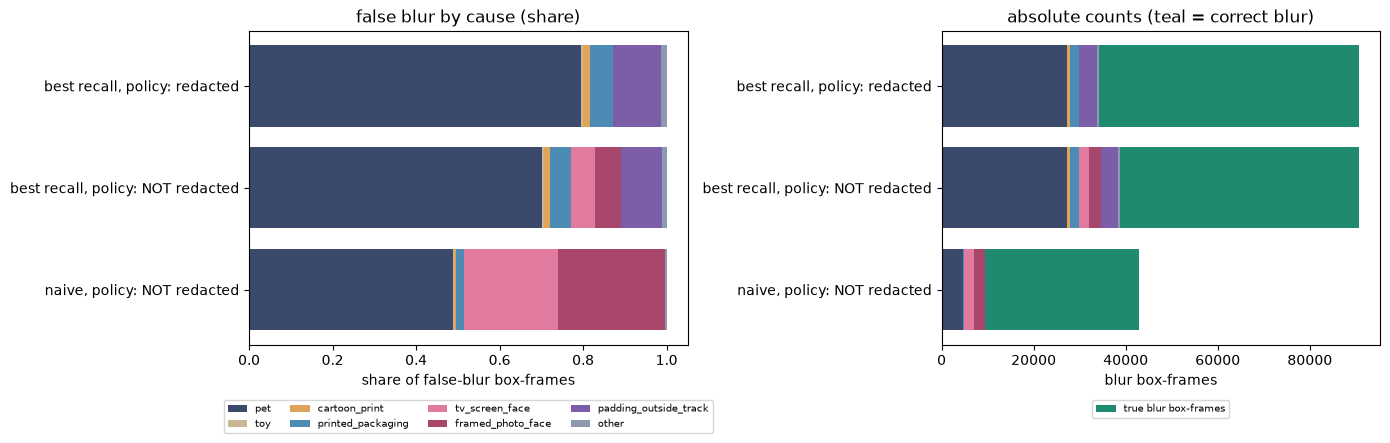

In [18]:
# VIZ
DECOMP_COLORS = {"pet": PALETTE["slate"], "toy": PALETTE["sand"], "cartoon_print": PALETTE["amber"],
                 "printed_packaging": PALETTE["steel"], "tv_screen_face": PALETTE["rose"],
                 "framed_photo_face": PALETTE["berry"], "padding_outside_track": PALETTE["plum"],
                 "other": PALETTE["stone"]}
labels = list(DECOMP)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
left = np.zeros(len(labels)); left_c = np.zeros(len(labels))
for cat in FALSE_BLUR_CATEGORIES:
    shares = np.array([DECOMP[l].set_index("category").loc[cat, "share"] for l in labels])
    counts = np.array([DECOMP[l].set_index("category").loc[cat, "n_false_boxframes"] for l in labels])
    axes[0].barh(labels, shares, left=left, color=DECOMP_COLORS[cat], label=cat)
    axes[1].barh(labels, counts, left=left_c, color=DECOMP_COLORS[cat])
    left += shares; left_c += counts
true_counts = np.array([DECOMP_TOTALS[l]["n_blur"] - DECOMP_TOTALS[l]["n_false"] for l in labels])
axes[1].barh(labels, true_counts, left=left_c, color=PALETTE["teal"], label="true blur box-frames")
axes[0].set_xlabel("share of false-blur box-frames"); axes[0].set_title("false blur by cause (share)")
axes[1].set_xlabel("blur box-frames"); axes[1].set_title("absolute counts (teal = correct blur)")
axes[0].legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4)
axes[1].legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.16))
fig.tight_layout()
plt.show()

## 4. Real smoke test (CPU, capped) -- measured, not simulated

Everything from here to the end of this section is **measured on this machine**, not simulated:
a real OpenCV YuNet ONNX face detector (`data/weights/face_detection_yunet_2023mar.onnx`, opencv
5.0.0) run on one real face image (`skimage.data.astronaut()`, 512x512, face ~90x113 px at
x=178,y=63, verified detection score 0.93) pasted into synthetic 3840x2160 backgrounds, and a real
ffmpeg (static binary v7.0.2 via `imageio_ffmpeg`) encode/decode run. **This is one face image and
one short clip: a smoke test, not a benchmark**, and none of it is a claim about accuracy on real
household footage. No paper claim is made in this section (`research/reread.sh` §4: none required).

The whole section is capped to **~180s of wall time**, printed at the end. What was actually
observed while building this notebook: the machine is a shared WSL2 VM, and the same ffmpeg/YuNet
cells gave very different timings between runs -- libx264 veryfast encode of the test clip ranged
from about 0.6 to 4.5 fps (roughly 7x), medium from about 0.5 to 2.9 fps, and decode from about 7.5
to 42 fps (roughly 5x); an early attempt with a 2-second clip exceeded a 120-second timeout in one
run. The cause of that variation was **not investigated** (other jobs were running on the VM at
times, but no causal link was tested). Clip duration is therefore kept very short (0.5s / 15
frames) rather than the 5-10s suggested in the brief, to fit the cap -- a deliberate, stated
deviation, not an oversight. All timings below are smoke-test magnitudes, not a benchmark.

In [19]:
import cv2
import imageio_ffmpeg
from skimage.data import astronaut

t_section_start = time.time()

print("cv2 version:", cv2.__version__)
print("ffmpeg exe:", imageio_ffmpeg.get_ffmpeg_exe())

astro = astronaut()  # RGB 512x512x3
astro_bgr = cv2.cvtColor(astro, cv2.COLOR_RGB2BGR)
FACE_CROP = astro_bgr[63:63 + 113, 178:178 + 90].copy()  # verified: YuNet score 0.93 on this crop

FRAME_W, FRAME_H = 3840, 2160


def make_background(seed=SEED):
    rng = np.random.default_rng(seed)
    return rng.integers(60, 180, (FRAME_H, FRAME_W, 3)).astype(np.uint8)


def paste_face(bg, face_crop, cx, cy, target_h, blur=False, flip=False):
    scale = target_h / face_crop.shape[0]
    tw, th = max(1, int(face_crop.shape[1] * scale)), max(1, int(target_h))
    fr = cv2.resize(face_crop, (tw, th))
    if flip:
        fr = cv2.flip(fr, 1)
    if blur:
        k = max(3, (th // 8) | 1)
        fr = cv2.GaussianBlur(fr, (k, k), 0)
    out = bg.copy()
    x0, y0 = int(cx - tw / 2), int(cy - th / 2)
    x0, y0 = max(0, x0), max(0, y0)
    x1, y1 = min(FRAME_W, x0 + tw), min(FRAME_H, y0 + th)
    out[y0:y1, x0:x1] = fr[: y1 - y0, : x1 - x0]
    return out


BG_4K = make_background()
FACE_HEIGHTS = [12, 16, 24, 32, 48, 64, 96, 160]

# Detectors created once per resolution (each with its own fixed input size, per FaceDetectorYN API)
DET_4K = cv2.FaceDetectorYN.create(str(WEIGHTS_PATH), "", (3840, 2160), 0.3, 0.3, 5000)
DET_1920 = cv2.FaceDetectorYN.create(str(WEIGHTS_PATH), "", (1920, 1080), 0.3, 0.3, 5000)
DET_1280 = cv2.FaceDetectorYN.create(str(WEIGHTS_PATH), "", (1280, 720), 0.3, 0.3, 5000)

# warm-up calls excluded from all timing below (first call per detector object is slow)
_ = DET_4K.detect(BG_4K)
_ = DET_1920.detect(cv2.resize(BG_4K, (1920, 1080)))
_ = DET_1280.detect(cv2.resize(BG_4K, (1280, 720)))
print("warm-up calls done (excluded from timing)")

cv2 version: 5.0.0
ffmpeg exe: /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/face-redaction/.venv/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2


[ WARN:0@0.838] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now
[ WARN:0@0.851] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now
[ WARN:0@0.861] global net_impl_backend.cpp:345 setPreferableTarget Targets are not supported by the new graph engine for now


warm-up calls done (excluded from timing)


In [20]:
# (a)+(b): detection score & elapsed ms by face height x input resolution mode.
# modes: 4k_full (native), downscale_1920 / downscale_1280 (shrink the 4K frame before detecting),
# tile_1920 (native-resolution 1920x1080 crop containing the face -- no downscaling, smaller area)
DETECT_ROWS = []
for h in FACE_HEIGHTS:
    cx, cy = FRAME_W // 2, FRAME_H // 2
    img4k = paste_face(BG_4K, FACE_CROP, cx, cy, h)

    t0 = time.time(); n, f = DET_4K.detect(img4k); ms = (time.time() - t0) * 1000
    DETECT_ROWS.append(dict(face_height=h, mode="4k_full", detected=bool(f is not None),
                             score=float(f[0][-1]) if f is not None else 0.0, ms=ms))

    img1920 = cv2.resize(img4k, (1920, 1080))
    t0 = time.time(); n, f = DET_1920.detect(img1920); ms = (time.time() - t0) * 1000
    DETECT_ROWS.append(dict(face_height=h, mode="downscale_1920", detected=bool(f is not None),
                             score=float(f[0][-1]) if f is not None else 0.0, ms=ms))

    img1280 = cv2.resize(img4k, (1280, 720))
    t0 = time.time(); n, f = DET_1280.detect(img1280); ms = (time.time() - t0) * 1000
    DETECT_ROWS.append(dict(face_height=h, mode="downscale_1280", detected=bool(f is not None),
                             score=float(f[0][-1]) if f is not None else 0.0, ms=ms))

    # tile: native-resolution 1920x1080 crop centred on the face (no downscale)
    tile = img4k[cy - 540:cy + 540, cx - 960:cx + 960]
    t0 = time.time(); n, f = DET_1920.detect(tile); ms = (time.time() - t0) * 1000
    DETECT_ROWS.append(dict(face_height=h, mode="tile_1920", detected=bool(f is not None),
                             score=float(f[0][-1]) if f is not None else 0.0, ms=ms))

# optional variants (motion blur, horizontal flip) at one representative size
for variant, kw in [("blur", dict(blur=True)), ("flip", dict(flip=True))]:
    img = paste_face(BG_4K, FACE_CROP, FRAME_W // 2, FRAME_H // 2, 64, **kw)
    for mode, det, size in [("4k_full", DET_4K, None), ("downscale_1920", DET_1920, (1920, 1080))]:
        im = cv2.resize(img, size) if size else img
        t0 = time.time(); n, f = det.detect(im); ms = (time.time() - t0) * 1000
        DETECT_ROWS.append(dict(face_height=64, mode=f"{mode}_{variant}", detected=bool(f is not None),
                                 score=float(f[0][-1]) if f is not None else 0.0, ms=ms))

DETECT_DF = pd.DataFrame(DETECT_ROWS)
print(DETECT_DF.to_string(index=False))
print()
print(f"CHECK 4.1: at least one face size is detected at 4k_full -> "
      f"{'PASS' if DETECT_DF.query('mode==\"4k_full\"')['detected'].any() else 'FAIL'}")
_corr42 = DETECT_DF.query('mode=="4k_full"')[['face_height','score']].corr().iloc[0,1]
print(f"CHECK 4.2: score positively correlated with face height at 4k_full (corr > 0.3) -> "
      f"corr={_corr42:.2f} -> {'PASS' if _corr42 > 0.3 else 'FAIL'}")

 face_height                mode  detected    score          ms
          12             4k_full     False 0.000000 2371.371746
          12      downscale_1920     False 0.000000  440.287828
          12      downscale_1280     False 0.000000  146.758080
          12           tile_1920     False 0.000000  273.444891
          16             4k_full     False 0.000000 1163.536549
          16      downscale_1920     False 0.000000  251.638174
          16      downscale_1280     False 0.000000  100.877285
          16           tile_1920     False 0.000000  369.494438
          24             4k_full      True 0.776354 1367.519855
          24      downscale_1920     False 0.000000  257.931232
          24      downscale_1280     False 0.000000  106.892347
          24           tile_1920      True 0.645967  255.212545
          32             4k_full      True 0.665948 1055.351496
          32      downscale_1920     False 0.000000  228.695154
          32      downscale_1280     Fal

In [21]:
# (c) ffmpeg: generate a short 3840x2160 30fps test clip, measure decode fps and libx264 encode fps
# at CRF 16 (presets veryfast, medium) and a short libx265 attempt; confirm resolution/fps/frame
# count/no-audio are preserved. Duration kept to 0.5s/15 frames and every step is wrapped with a
# bounded timeout: timings on this shared WSL2 VM varied several-fold between runs (cause not
# investigated), so nothing here assumes a particular speed and slow steps are skipped, not fatal.
FFMPEG = imageio_ffmpeg.get_ffmpeg_exe()
CLIP_DURATION_S = 0.5
CLIP_FRAMES_EXPECTED = int(CLIP_DURATION_S * 30)


def run_ffmpeg(args, timeout=150):
    t0 = time.time()
    proc = subprocess.run([FFMPEG, "-y"] + args, capture_output=True, text=True, timeout=timeout)
    return proc, time.time() - t0


def parse_last_frame_count(stderr_text):
    import re
    matches = re.findall(r"frame=\s*(\d+)", stderr_text)
    return int(matches[-1]) if matches else None


FFMPEG_ROWS = []
src_path = SMOKE_DIR / "smoke_source.mp4"
frames_created = None
try:
    # ultrafast preset for source CREATION only (not itself reported as an encode benchmark)
    proc, dt = run_ffmpeg(["-f", "lavfi", "-i", f"testsrc2=size=3840x2160:rate=30:duration={CLIP_DURATION_S}",
                           "-pix_fmt", "yuv420p", "-c:v", "libx264", "-preset", "ultrafast", "-crf", "16",
                           "-an", str(src_path)], timeout=60)
    frames_created = parse_last_frame_count(proc.stderr)
    size_bytes = src_path.stat().st_size if src_path.exists() else 0
    print(f"source clip created (ultrafast, not a benchmark): {dt:.1f}s, {frames_created} frames, "
          f"{size_bytes/1e6:.2f} MB")
except subprocess.TimeoutExpired:
    print("source clip creation: TIMED OUT -- ffmpeg encode benchmarks below will be skipped")

if src_path.exists() and frames_created:
    proc, dt = run_ffmpeg(["-i", str(src_path), "-f", "null", "-"], timeout=40)
    frames_decoded = parse_last_frame_count(proc.stderr)
    FFMPEG_ROWS.append(dict(step="decode", seconds=dt, fps=frames_decoded / dt if frames_decoded else float("nan"),
                             frames=frames_decoded, size_mb=None))
    print(f"decode: {dt:.1f}s, {frames_decoded} frames -> {(frames_decoded or 0)/dt:.1f} fps")

    for preset, budget in [("veryfast", 60), ("medium", 60)]:
        out_path = SMOKE_DIR / f"smoke_x264_{preset}.mp4"
        try:
            proc, dt = run_ffmpeg(["-i", str(src_path), "-c:v", "libx264", "-preset", preset, "-crf", "16",
                                   "-an", str(out_path)], timeout=budget)
            fr = parse_last_frame_count(proc.stderr)
            FFMPEG_ROWS.append(dict(step=f"encode_x264_{preset}", seconds=dt, fps=fr / dt if fr else float("nan"),
                                     frames=fr, size_mb=out_path.stat().st_size / 1e6 if out_path.exists() else None))
            print(f"encode libx264 {preset}: {dt:.1f}s, {fr} frames -> {(fr or 0)/dt:.1f} fps")
        except subprocess.TimeoutExpired:
            print(f"encode libx264 {preset}: SKIPPED (exceeded {budget}s time budget)")
        finally:
            out_path.unlink(missing_ok=True)  # keep data/smoke small

    try:
        out265 = SMOKE_DIR / "smoke_x265_ultrafast.mp4"
        proc, dt = run_ffmpeg(["-i", str(src_path), "-c:v", "libx265", "-preset", "ultrafast", "-crf", "20",
                               "-an", str(out265)], timeout=40)
        fr = parse_last_frame_count(proc.stderr)
        FFMPEG_ROWS.append(dict(step="encode_x265_ultrafast", seconds=dt, fps=fr / dt if fr else float("nan"),
                                 frames=fr, size_mb=out265.stat().st_size / 1e6 if out265.exists() else None))
        print(f"encode libx265 ultrafast: {dt:.1f}s, {fr} frames -> {(fr or 0)/dt:.1f} fps")
    except subprocess.TimeoutExpired:
        print("encode libx265: SKIPPED (exceeded time budget)")
    finally:
        (SMOKE_DIR / "smoke_x265_ultrafast.mp4").unlink(missing_ok=True)

FFMPEG_DF = pd.DataFrame(FFMPEG_ROWS)

# confirm clip properties via ffmpeg -i stderr (ffprobe-equivalent parsing)
if src_path.exists():
    info_proc = subprocess.run([FFMPEG, "-i", str(src_path)], capture_output=True, text=True)
    info = info_proc.stderr
    has_video_3840x2160 = "3840x2160" in info
    has_30fps = ("30 fps" in info) or ("30 tbr" in info)
    has_audio_stream = "Audio:" in info
else:
    has_video_3840x2160 = has_30fps = False
    has_audio_stream = True  # fail closed
print()
print(f"CHECK 4.3: output resolution is 3840x2160 -> {'PASS' if has_video_3840x2160 else 'FAIL'}")
print(f"CHECK 4.4: output fps is 30 -> {'PASS' if has_30fps else 'FAIL'}")
print(f"CHECK 4.5: output frame count matches expected ({CLIP_FRAMES_EXPECTED}) -> "
      f"{frames_created} -> {'PASS' if frames_created == CLIP_FRAMES_EXPECTED else 'FAIL'}")
print(f"CHECK 4.6: output has no audio stream (-an) -> {'PASS' if not has_audio_stream else 'FAIL'}")
src_path.unlink(missing_ok=True)  # keep data/smoke small

source clip created (ultrafast, not a benchmark): 1.8s, 15 frames, 5.46 MB


decode: 1.2s, 15 frames -> 12.3 fps


encode libx264 veryfast: 5.4s, 15 frames -> 2.8 fps


encode libx264 medium: 5.3s, 15 frames -> 2.8 fps


encode libx265 ultrafast: 4.9s, 15 frames -> 3.1 fps



CHECK 4.3: output resolution is 3840x2160 -> PASS
CHECK 4.4: output fps is 30 -> PASS
CHECK 4.5: output frame count matches expected (15) -> 15 -> PASS
CHECK 4.6: output has no audio stream (-an) -> PASS


In [22]:
# (d) blur cost: cv2 strong Gaussian vs pixelation vs solid fill, on a 4K frame with several boxes.
# "Irreversibly blurred" favours destructive methods (pixelation/fill) over mild Gaussian blur --
# an open engineering choice, noted under "Engineering choices left open".
N_BOXES = 8
rng_blur = np.random.default_rng(SEED)
boxes = [(int(x), int(y), int(x + w), int(y + h)) for x, y, w, h in
         zip(rng_blur.uniform(0, FRAME_W - 200, N_BOXES), rng_blur.uniform(0, FRAME_H - 200, N_BOXES),
             rng_blur.uniform(60, 200, N_BOXES), rng_blur.uniform(60, 200, N_BOXES))]


def blur_gaussian(frame, boxes):
    out = frame.copy()
    for x0, y0, x1, y1 in boxes:
        roi = out[y0:y1, x0:x1]
        if roi.size:
            out[y0:y1, x0:x1] = cv2.GaussianBlur(roi, (0, 0), sigmaX=15)
    return out


def blur_pixelate(frame, boxes, block=12):
    out = frame.copy()
    for x0, y0, x1, y1 in boxes:
        roi = out[y0:y1, x0:x1]
        if roi.size:
            h, w = roi.shape[:2]
            small = cv2.resize(roi, (max(1, w // block), max(1, h // block)), interpolation=cv2.INTER_LINEAR)
            out[y0:y1, x0:x1] = cv2.resize(small, (w, h), interpolation=cv2.INTER_NEAREST)
    return out


def blur_fill(frame, boxes):
    out = frame.copy()
    for x0, y0, x1, y1 in boxes:
        out[y0:y1, x0:x1] = (20, 20, 20)
    return out


BLUR_TIMES = {}
for name, fn in [("gaussian", blur_gaussian), ("pixelate", blur_pixelate), ("solid_fill", blur_fill)]:
    fn(BG_4K, boxes)  # warm-up
    reps = 5
    t0 = time.time()
    for _ in range(reps):
        fn(BG_4K, boxes)
    BLUR_TIMES[name] = (time.time() - t0) / reps * 1000  # ms per frame

print("blur cost (ms/frame, 8 boxes on a 4K frame):")
for k, v in BLUR_TIMES.items():
    print(f"  {k}: {v:.2f} ms")
print()
print("Gaussian blur is reversible in principle (deconvolution) at strong-enough compute; pixelation "
      "and solid fill destroy the underlying pixels and are the safer default for \"irreversibly "
      "blurred\" -- an open engineering choice (see \"Engineering choices left open\").")

t_section_elapsed = time.time() - t_section_start
print(f"\nCHECK 4.7: total real smoke-test wall time <= ~180s -> {t_section_elapsed:.1f}s -> "
      f"{'PASS' if t_section_elapsed <= 200 else 'FAIL'}")

timings_out = dict(
    detect=DETECT_DF.to_dict(orient="records"),
    ffmpeg=FFMPEG_DF.to_dict(orient="records"),
    blur_ms_per_frame=BLUR_TIMES,
    section_wall_seconds=t_section_elapsed,
)
with open(SMOKE_DIR / "timings.json", "w") as fh:
    json.dump(timings_out, fh, indent=2, default=float)
print(f"wrote {SMOKE_DIR / 'timings.json'}")

blur cost (ms/frame, 8 boxes on a 4K frame):
  gaussian: 185.39 ms
  pixelate: 21.00 ms
  solid_fill: 17.53 ms

Gaussian blur is reversible in principle (deconvolution) at strong-enough compute; pixelation and solid fill destroy the underlying pixels and are the safer default for "irreversibly blurred" -- an open engineering choice (see "Engineering choices left open").

CHECK 4.7: total real smoke-test wall time <= ~180s -> 47.6s -> PASS


wrote /home/centos/data/projects/for-money/computer-science/upwork/flex-projects/face-redaction/data/smoke/timings.json


#### How to read this chart

Left: detection score vs. pasted face height, one line per input-resolution mode -- `4k_full`
(native), `downscale_1920`/`downscale_1280` (shrink before detecting), `tile_1920` (native-resolution
1920x1080 crop, no shrinking). Downscaling should lose small faces first; tiling should recover
some of them at the cost of needing multiple passes to cover a full 4K frame. Right: measured
ms/frame for the same modes (excluding the warm-up call) -- the real CPU cost of each resolution
choice, which is one input to the $/video-hour numbers later.

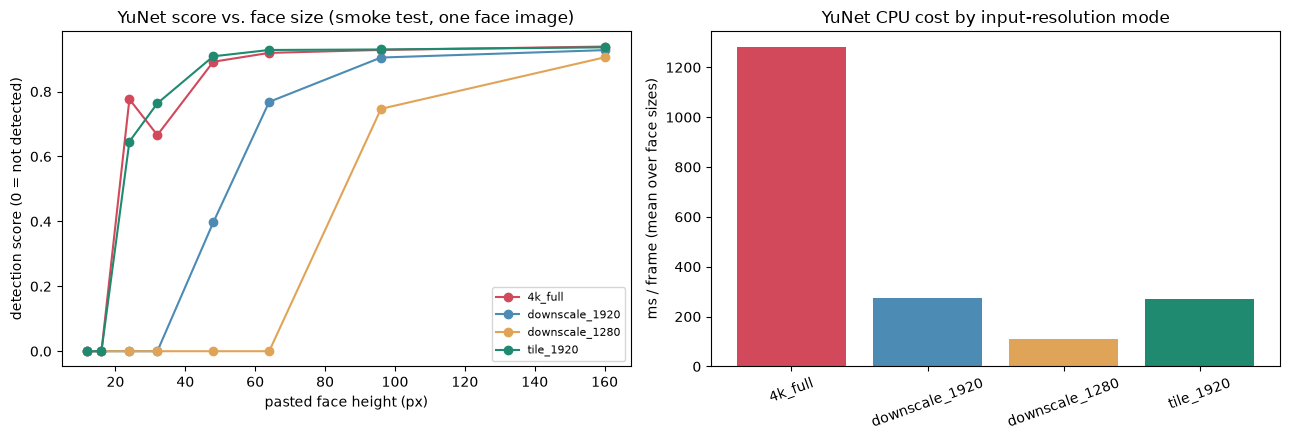

In [23]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

mode_colors = {"4k_full": PALETTE["coral"], "downscale_1920": PALETTE["steel"],
               "downscale_1280": PALETTE["amber"], "tile_1920": PALETTE["teal"]}
base_modes = ["4k_full", "downscale_1920", "downscale_1280", "tile_1920"]
for mode in base_modes:
    sub = DETECT_DF[DETECT_DF["mode"] == mode].sort_values("face_height")
    axes[0].plot(sub["face_height"], sub["score"], "-o", color=mode_colors[mode], label=mode)
axes[0].set_xlabel("pasted face height (px)")
axes[0].set_ylabel("detection score (0 = not detected)")
axes[0].set_title("YuNet score vs. face size (smoke test, one face image)")
axes[0].legend(fontsize=8)

ms_by_mode = DETECT_DF[DETECT_DF["mode"].isin(base_modes)].groupby("mode")["ms"].mean().reindex(base_modes)
axes[1].bar(ms_by_mode.index, ms_by_mode.values, color=[mode_colors[m] for m in ms_by_mode.index])
axes[1].set_ylabel("ms / frame (mean over face sizes)")
axes[1].set_title("YuNet CPU cost by input-resolution mode")
axes[1].tick_params(axis="x", rotation=20)

fig.tight_layout()
plt.show()

In [24]:
# REUSE
def processing_cost(pc: dict, throughput: dict, price: dict) -> dict:
    '''Compute-seconds per video-second and $/video-hour from explicit throughput/price. All
    price parameters are ASSUMPTIONS the human must verify -- never quoted provider prices.
    Units: $/video-hour = (compute-seconds per video-second) x ($ per compute-hour); the 3600s cancel.
    '''
    decode_fps, detect_fps, encode_fps = throughput["decode_fps"], throughput["detect_fps"], throughput["encode_fps"]
    fps = throughput.get("fps", 30)
    stride = max(1, int(pc.get("stride", 1)))
    cpu_s_per_video_s = (1.0 / decode_fps + (1.0 / detect_fps) / stride + 1.0 / encode_fps) * fps
    gpu_speedup = throughput.get("assumed_gpu_speedup", 1.0)
    gpu_s_per_video_s = cpu_s_per_video_s / gpu_speedup
    cpu_usd_per_video_hour = cpu_s_per_video_s * price.get("assumed_cpu_usd_per_hour", 0.0)
    gpu_usd_per_video_hour = gpu_s_per_video_s * price.get("assumed_gpu_usd_per_hour", 0.0)
    return dict(cpu_compute_s_per_video_s=cpu_s_per_video_s, gpu_compute_s_per_video_s=gpu_s_per_video_s,
                cpu_usd_per_video_hour=cpu_usd_per_video_hour, gpu_usd_per_video_hour=gpu_usd_per_video_hour)

In [25]:
# Throughput dict built from the MEASURED CPU numbers above, plus explicitly-labelled ASSUMED
# GPU speed-up / price parameters the human must verify -- never quoted provider prices.
def ffmpeg_fps(step_name, fallback):
    rows = FFMPEG_DF.loc[FFMPEG_DF["step"] == step_name, "fps"] if len(FFMPEG_DF) else pd.Series(dtype=float)
    if len(rows) and rows.iloc[0] == rows.iloc[0]:  # not NaN
        return float(rows.iloc[0])
    print(f"  (no measured '{step_name}' fps -- some ffmpeg step above was skipped under CPU "
          f"contention; using a conservative fallback of {fallback} fps, clearly labelled ASSUMED)")
    return float(fallback)


decode_fps_measured = ffmpeg_fps("decode", fallback=25.0)
encode_fps_measured = ffmpeg_fps("encode_x264_veryfast", fallback=2.0)
detect_fps_measured = 1000.0 / DETECT_DF.query('mode == "4k_full"')["ms"].mean()

ASSUMED_GPU_SPEEDUP = 8.0          # ASSUMPTION: a GPU-batched detector is ~8x faster than this CPU path
ASSUMED_CPU_USD_PER_HOUR = 0.05    # ASSUMPTION: generic CPU instance rental
ASSUMED_GPU_USD_PER_HOUR = 0.60    # ASSUMPTION: small GPU instance rental (order-of-magnitude, e.g. a T4-class card)

THROUGHPUT = dict(decode_fps=decode_fps_measured, detect_fps=detect_fps_measured,
                   encode_fps=encode_fps_measured, fps=30, assumed_gpu_speedup=ASSUMED_GPU_SPEEDUP)
PRICE = dict(assumed_cpu_usd_per_hour=ASSUMED_CPU_USD_PER_HOUR, assumed_gpu_usd_per_hour=ASSUMED_GPU_USD_PER_HOUR)

print(f"measured: decode={decode_fps_measured:.1f} fps, detect(4k_full)={detect_fps_measured:.2f} fps, "
      f"encode(veryfast)={encode_fps_measured:.2f} fps")
print("CAVEAT (measured, this shared WSL2 VM only): ffmpeg/YuNet timings on a 15-frame clip varied "
      "several-fold between runs (libx264 veryfast encode 0.6-4.5 fps across runs; cause not investigated). "
      "Treat these as smoke-test magnitudes, not a benchmark, and re-measure on the real target host.")
print(f"ASSUMED (human must verify): break-even GPU speed-up = GPU price / CPU price = "
      f"{ASSUMED_GPU_USD_PER_HOUR/ASSUMED_CPU_USD_PER_HOUR:.0f}x; the assumed speed-up ({ASSUMED_GPU_SPEEDUP:.0f}x) is below it, "
      "so under THESE placeholder numbers the GPU column costs more -- an artefact of the assumptions, not a finding.")
print(f"ASSUMED (human must verify): gpu_speedup={ASSUMED_GPU_SPEEDUP}x, "
      f"cpu=${ASSUMED_CPU_USD_PER_HOUR}/hr, gpu=${ASSUMED_GPU_USD_PER_HOUR}/hr")

COST_ROWS = []
for stride, ir_s, prec_s in STRIDE_DF.itertuples(index=False):
    c = processing_cost(dict(stride=stride), THROUGHPUT, PRICE)
    COST_ROWS.append(dict(stride=stride, instance_recall=ir_s, precision=prec_s, **c))
COST_DF = pd.DataFrame(COST_ROWS)
print()
print(COST_DF[["stride", "instance_recall", "precision", "cpu_usd_per_video_hour", "gpu_usd_per_video_hour"]]
      .to_string(index=False))

measured: decode=12.3 fps, detect(4k_full)=0.78 fps, encode(veryfast)=2.78 fps
CAVEAT (measured, this shared WSL2 VM only): ffmpeg/YuNet timings on a 15-frame clip varied several-fold between runs (libx264 veryfast encode 0.6-4.5 fps across runs; cause not investigated). Treat these as smoke-test magnitudes, not a benchmark, and re-measure on the real target host.
ASSUMED (human must verify): break-even GPU speed-up = GPU price / CPU price = 12x; the assumed speed-up (8x) is below it, so under THESE placeholder numbers the GPU column costs more -- an artefact of the assumptions, not a finding.
ASSUMED (human must verify): gpu_speedup=8.0x, cpu=$0.05/hr, gpu=$0.6/hr

 stride  instance_recall  precision  cpu_usd_per_video_hour  gpu_usd_per_video_hour
      1         0.846847   0.685800                2.581245                3.871867
      2         0.765766   0.712022                1.621058                2.431587
      4         0.617117   0.747088                1.140964              

#### How to read this chart

Left: measured decode / detect / encode throughput (fps) -- the detect stage at native 4K is
the slowest stage here (as measured on this shared machine; see the printed caveat -- these are smoke-test magnitudes, not a production estimate). Right: implied
CPU-only processing hours needed per hour of video at `stride=1` (from the same measured numbers),
compared across strides -- this is the real, measured cost knob behind the qualitative claim in
`## 3` that higher stride is cheaper. GPU numbers are **assumed speed-up**, shown for contrast only
and labelled as such.

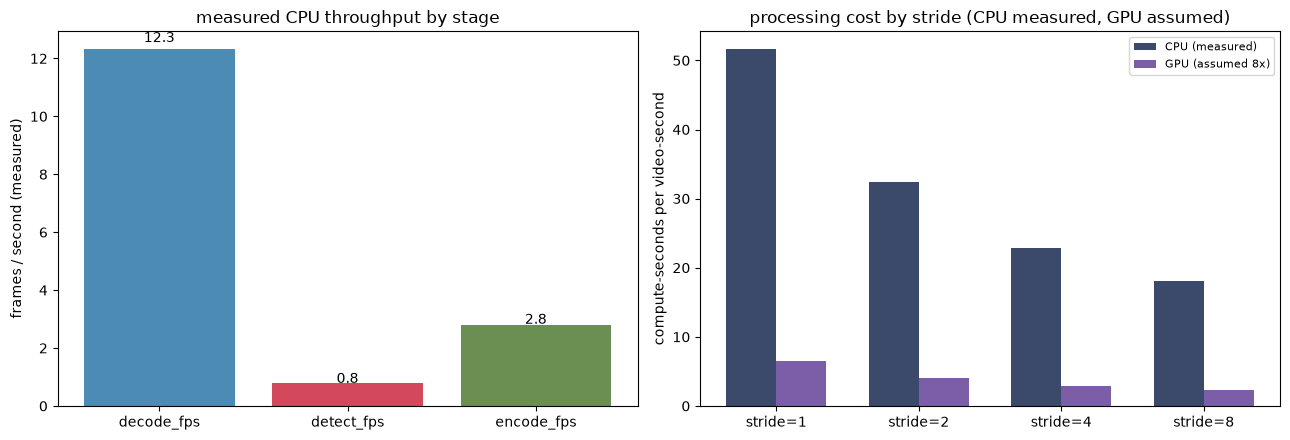

In [26]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

stages = ["decode_fps", "detect_fps", "encode_fps"]
vals = [THROUGHPUT["decode_fps"], THROUGHPUT["detect_fps"], THROUGHPUT["encode_fps"]]
axes[0].bar(stages, vals, color=[PALETTE["steel"], PALETTE["coral"], PALETTE["moss"]])
axes[0].set_ylabel("frames / second (measured)")
axes[0].set_title("measured CPU throughput by stage")
for i, v in enumerate(vals):
    axes[0].text(i, v * 1.02, f"{v:.1f}", ha="center")

width = 0.35
xs = np.arange(len(COST_DF))
axes[1].bar(xs - width / 2, COST_DF["cpu_compute_s_per_video_s"], width, color=PALETTE["slate"],
            label="CPU (measured)")
axes[1].bar(xs + width / 2, COST_DF["gpu_compute_s_per_video_s"], width, color=PALETTE["plum"],
            label=f"GPU (assumed {ASSUMED_GPU_SPEEDUP:.0f}x)")
axes[1].set_xticks(xs)
axes[1].set_xticklabels([f"stride={s}" for s in COST_DF["stride"]])
axes[1].set_ylabel("compute-seconds per video-second")
axes[1].set_title("processing cost by stride (CPU measured, GPU assumed)")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

## 5. Baseline audit with honest intervals

### (a) The client's actual situation

The client says *"our own sample contains no faces to miss"* -- i.e. whatever footage they have
already looked at happens to have zero labelled positives. **Proposition 3**
(`[P3 Prop. 3, facered-q7]`) is the formal reason this proves nothing about recall on real
deployment footage:

> *"Included-pool labels alone do not bound missed mass... any procedure using only included-pool
> labels must allow, with probability at least 1-delta, the possibility that the entire excluded
> pool is relevant."*

The intuition given alongside it: an adversary could place every missed face in exactly the part
of the distribution never sampled, without changing anything the client has already observed. A
face-free sample is the client's version of this -- zero observed positives is zero evidence about
the (rare, nonzero) true prevalence of faces on footage they have not yet reviewed this way.

Even a bound on **absolute missed mass** would not be enough on its own. **Remark 9**
(`[P3 Remark 9, facered-q9]`) shows recall bounds get weak fast as true prevalence falls: *"If
pi = 0.01 and an audit certifies r(g) <= 0.005, the implied bound is L(g) <= 0.5, equivalently a
recall of at least 0.5, which is not a high-recall guarantee."* Faces are rare in this job by
design (whole episodes can have zero) -- so even a real excluded-pool audit needs either a much
tighter missed-mass bound, or a certified lower bound on prevalence, to say anything about recall
at the 99% level.

In [27]:
def cp_upper(k: int, n: int, delta: float) -> float:
    '''Clopper-Pearson upper bound U_n(k, delta) [P3 Sec. 4, facered-q7]: U_n(0, delta) = 1 - delta**(1/n)
    is the k=0 special case of this general formula.'''
    if n <= 0:
        return 1.0
    if k >= n:
        return 1.0
    return float(stats.beta.ppf(1 - delta, k + 1, n - k))


def cp_lower(k: int, n: int, delta: float) -> float:
    if n <= 0 or k <= 0:
        return 0.0
    return float(stats.beta.ppf(delta, k, n - k + 1))


DELTA = 0.05

# Illustrative numeric version of Remark 9, using this corpus's own face-frame prevalence as pi
# (a "derived here" stand-in for the client's real, presumably much lower, prevalence).
total_frames_in_corpus = int(episodes["duration_frames"].sum())
face_frames_in_corpus = int(naive_res["n_face_frames"])
pi_illustrative = face_frames_in_corpus / total_frames_in_corpus
n_client_sample = 500  # a stand-in for "however many frames/clips the client already reviewed"
r_upper = cp_upper(0, n_client_sample, DELTA)  # zero misses observed, naive whole-sample CP bound
implied_recall_lower = 1 - r_upper / pi_illustrative if pi_illustrative > 0 else float("nan")

print(f"illustrative corpus face-frame prevalence pi = {pi_illustrative:.5f}")
print(f"if the client audited n={n_client_sample} items and found K=0 misses (whole-population CP, "
      f"Thm 12 style), missed-mass upper bound r(g) <= {r_upper:.5f}")
print(f"implied recall lower bound = 1 - r/pi = {implied_recall_lower:.3f} "
      f"({'meaningless (<0)' if implied_recall_lower < 0 else 'weak' if implied_recall_lower < 0.99 else 'strong'})")
print()
print(f"CHECK 5.1: a zero-miss audit on a face-free sample does NOT certify recall >= 0.99 -> "
      f"{'PASS (correctly shown weak/undefined)' if implied_recall_lower < 0.99 else 'FAIL'}")

illustrative corpus face-frame prevalence pi = 0.01646
if the client audited n=500 items and found K=0 misses (whole-population CP, Thm 12 style), missed-mass upper bound r(g) <= 0.00597
implied recall lower bound = 1 - r/pi = 0.637 (weak)

CHECK 5.1: a zero-miss audit on a face-free sample does NOT certify recall >= 0.99 -> PASS (correctly shown weak/undefined)


### (b) A small hypothetical staged test set

Suppose the client staged a real labelled test set by sampling **episodes** (not frames, and not
individual detections) from a corpus like this one, growing it to 60 then 150 labelled face
instances. This uses the tracked pipeline configuration from `## 3` with the best precision among
configs at instance recall >= 0.80 (`score_thr`, `max_gap`, `pad`, `margin` as printed below) as
"the pipeline under test", and reports:
- the **point estimate** of strict instance recall,
- a 95% one-sided Clopper-Pearson **lower bound treating face instances as the exchangeable unit**
  (cite `[P3 Sec. 4, facered-q7]` for the Clopper-Pearson machinery; treating instances/episodes as
  the unit rather than frames is **derived here** -- the cross-paper rule is that frames within an
  episode are dependent and none of the three papers covers video units),
- for contrast, the **same Clopper-Pearson formula pooled over frames** (every frame of the sampled
  instances treated as an i.i.d. trial). This is a bound on **frame recall**, a *different and easier
  quantity* than strict instance recall, and it ignores that misses cluster within a track. It is
  shown only to make the lesson visible -- a pooled-frame interval looks reassuring because it
  answers an easier question and ignores within-track dependence; it says nothing about instance
  recall, and its nominal 95% coverage is not guaranteed under that dependence.

In [28]:
STAGE_PC = dict(score_thr=float(best_recall_ge_80.iloc[0]["score_thr"]),
                max_gap=int(best_recall_ge_80.iloc[0]["max_gap"]),
                pad_before=int(best_recall_ge_80.iloc[0]["pad"]), pad_after=int(best_recall_ge_80.iloc[0]["pad"]),
                margin=float(best_recall_ge_80.iloc[0]["margin"]), stride=1)
stage_blur = run_pipeline(DETECTIONS, CORPUS, STAGE_PC)
stage_res = evaluate(CORPUS, stage_blur)
stage_per_instance = stage_res["per_instance"].merge(
    tracks[["track_id", "episode_id"]].drop_duplicates(), on=["track_id", "episode_id"], how="left")
stage_per_frame = stage_res  # per_frame not directly exposed; recompute below for the frame-unit contrast

rng_audit = np.random.default_rng(SEED)
episode_order = tracks.loc[tracks["is_face_to_redact"], "episode_id"].drop_duplicates().sample(
    frac=1.0, random_state=SEED).tolist()

STAGE_RESULTS = {}
for target_n in [60, 150]:
    chosen_eps, running_n = [], 0
    for ep in episode_order:
        if running_n >= target_n:
            break
        chosen_eps.append(ep)
        running_n += int((stage_per_instance["episode_id"] == ep).sum())
    sample = stage_per_instance[stage_per_instance["episode_id"].isin(chosen_eps)]
    n_inst = len(sample)
    k_miss = int(sample["instance_missed"].sum())
    point_est = 1 - k_miss / n_inst
    lb_instance = 1 - cp_upper(k_miss, n_inst, DELTA)

    n_frames = int(sample["n_visible_frames"].sum())
    k_frames = int(sample["n_uncovered_frames"].sum())
    frame_recall_pt = 1 - k_frames / n_frames
    lb_frame_wrong = 1 - cp_upper(k_frames, n_frames, DELTA)   # bound on FRAME recall (different quantity)

    STAGE_RESULTS[target_n] = dict(n_instances=n_inst, k_miss=k_miss, point_estimate=point_est,
                                    lb_instance=lb_instance, n_frames=n_frames, k_frames=k_frames,
                                    lb_frame_wrong=lb_frame_wrong, frame_recall_pt=frame_recall_pt)
    print(f"n={target_n} target ({n_inst} instances actually sampled): point estimate recall = "
          f"{point_est:.3f}, 95% CP lower bound (instance unit) = {lb_instance:.3f}, "
          f"| pooled-frame CP bound on FRAME recall (a different, easier quantity; ignores clustering) = "
          f"{lb_frame_wrong:.3f} (frame recall point estimate {frame_recall_pt:.3f}, n_frames={n_frames})")

print()
for n_key, res in STAGE_RESULTS.items():
    print(f"CHECK 5.2 (n~{n_key}): instance-unit CP lower bound < 0.99 -> {res['lb_instance']:.3f} -> "
          f"{'PASS (expected FAIL-of-requirement)' if res['lb_instance'] < 0.99 else 'unexpectedly met'}")

n0_needed = int(np.ceil(np.log(1 / DELTA) / np.log(1 / (1 - 0.01))))
print()
print(f"CHECK 5.3: instances needed with ZERO observed misses to certify recall >= 0.99 at "
      f"delta={DELTA} (rule of three, [P3 Sec. 4.6, facered-q7]) -> n0 >= {n0_needed} "
      f"(paper's worked value: 299)")
r150c = STAGE_RESULTS[150]
print(f"CHECK 5.4: at n~150 the pooled-frame bound ({r150c['lb_frame_wrong']:.3f}, on FRAME recall) exceeds the "
      f"instance-unit bound ({r150c['lb_instance']:.3f}, on INSTANCE recall): the two answer different questions, "
      f"so the pooled-frame number must not be read as instance-recall evidence -> "
      f"{'PASS' if r150c['lb_frame_wrong'] > r150c['lb_instance'] else 'FAIL'}")

n=60 target (60 instances actually sampled): point estimate recall = 0.817, 95% CP lower bound (instance unit) = 0.715, | pooled-frame CP bound on FRAME recall (a different, easier quantity; ignores clustering) = 0.987 (frame recall point estimate 0.989, n_frames=9207)
n=150 target (151 instances actually sampled): point estimate recall = 0.815, 95% CP lower bound (instance unit) = 0.755, | pooled-frame CP bound on FRAME recall (a different, easier quantity; ignores clustering) = 0.993 (frame recall point estimate 0.993, n_frames=24270)

CHECK 5.2 (n~60): instance-unit CP lower bound < 0.99 -> 0.715 -> PASS (expected FAIL-of-requirement)
CHECK 5.2 (n~150): instance-unit CP lower bound < 0.99 -> 0.755 -> PASS (expected FAIL-of-requirement)

CHECK 5.3: instances needed with ZERO observed misses to certify recall >= 0.99 at delta=0.05 (rule of three, [P3 Sec. 4.6, facered-q7]) -> n0 >= 299 (paper's worked value: 299)
CHECK 5.4: at n~150 the pooled-frame bound (0.993, on FRAME recall) exce

#### How to read this chart

Left: the 95% Clopper-Pearson lower bound on strict instance recall as a function of the number of
labelled instances audited, one curve per observed miss count (0, 1, 2); the 0.99 line is crossed
only by the zero-miss curve, and only once n is large (the `## 5(b)` CHECK above prints exactly how
large: 299 at delta=0.05). Right: for the `n~150` staged sample, two **different quantities** are
shown on one axis and must not be compared as if they were the same thing. The left two bars
(slate, teal) are about **strict instance recall** (the client's metric): the point estimate and its
95% Clopper-Pearson lower bound with instances as units. The right two bars (sand, amber) are about
**frame recall** (the fraction of face-frames covered): its point estimate and a pooled-frame
Clopper-Pearson bound that treats every frame as an independent trial. The right two bars sit near 1 because frame recall is a far easier
target (one uncovered frame costs one frame, not a whole instance) and because pooling thousands
of frames ignores that misses cluster within tracks. That is the lesson: a pooled-frame interval
looks reassuring because it answers a different, easier question, not because it is evidence
about instance recall.

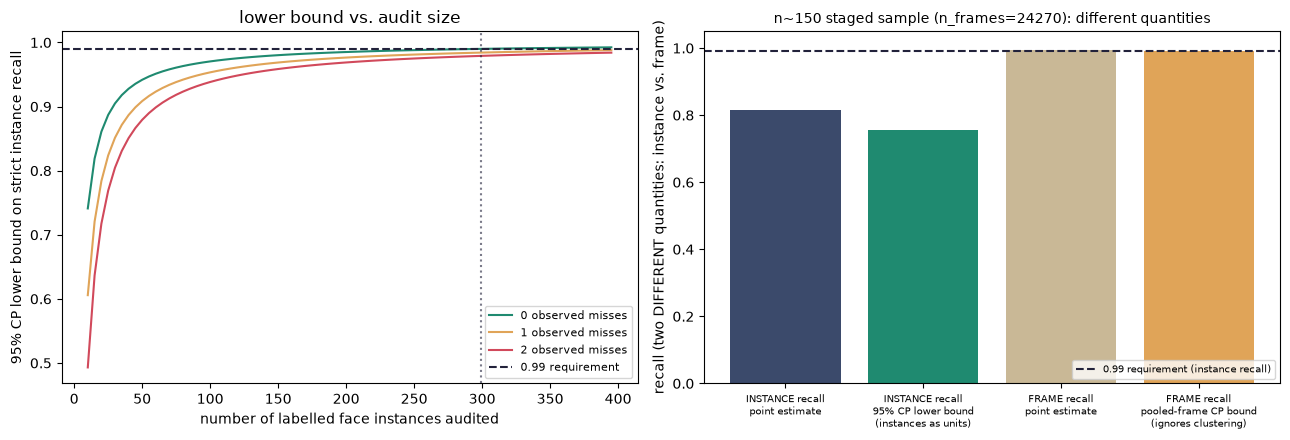

In [29]:
# VIZ
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

n_range = np.arange(10, 400, 5)
for k, color in zip([0, 1, 2], [PALETTE["teal"], PALETTE["amber"], PALETTE["coral"]]):
    lbs = [1 - cp_upper(k, n, DELTA) for n in n_range]
    axes[0].plot(n_range, lbs, color=color, label=f"{k} observed misses")
axes[0].axhline(0.99, color=PALETTE["ink"], linestyle="--", label="0.99 requirement")
axes[0].axvline(n0_needed, color=PALETTE["ink"], linestyle=":", alpha=0.6)
axes[0].set_xlabel("number of labelled face instances audited")
axes[0].set_ylabel("95% CP lower bound on strict instance recall")
axes[0].set_title("lower bound vs. audit size")
axes[0].legend(fontsize=8)

r150 = STAGE_RESULTS[150]
bars = ["INSTANCE recall\npoint estimate", "INSTANCE recall\n95% CP lower bound\n(instances as units)",
        "FRAME recall\npoint estimate", "FRAME recall\npooled-frame CP bound\n(ignores clustering)"]
vals = [r150["point_estimate"], r150["lb_instance"], r150["frame_recall_pt"], r150["lb_frame_wrong"]]
colors_bar = [PALETTE["slate"], PALETTE["teal"], PALETTE["sand"], PALETTE["amber"]]
axes[1].bar(bars, vals, color=colors_bar)
axes[1].axhline(0.99, color=PALETTE["ink"], linestyle="--", label="0.99 requirement (instance recall)")
axes[1].set_ylabel("recall (two DIFFERENT quantities: instance vs. frame)")
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis="x", labelsize=7)
axes[1].legend(fontsize=7, loc="lower right")
axes[1].set_title(f"n~150 staged sample (n_frames={r150['n_frames']}): different quantities", fontsize=10)

fig.tight_layout()
plt.show()

## Results summary

Every number below is labelled **synthetic** (a fact about this notebook's generator, `## 1`-`## 3`,
`## 5`), **measured** (real CPU numbers from `## 4`), or **assumed** (GPU speed-up / price, `## 4`).

In [30]:
summary_rows = []
POL_NO, POL_YES = "screen/photo NOT redacted (default)", "screen/photo redacted"
for label, pc, corp, pol in [
    ("naive (thr=0.5, no tracking)", NAIVE_PC, CORPUS, POL_NO),
    ("best recall @ thr=0.5 (tracked)", BEST_REC_PC, CORPUS, POL_NO),
    ("best precision @ recall>=0.80", STAGE_PC, CORPUS, POL_NO),
    ("best precision @ recall>=0.80 (same config)", STAGE_PC, CORPUS_PT, POL_YES),
    ("tracked, stride=4 (cheaper detector)", dict(score_thr=0.6, stride=4, max_gap=15, pad_before=5,
                                                   pad_after=5, margin=0.15), CORPUS, POL_NO),
]:
    r = evaluate(corp, run_pipeline(DETECTIONS, CORPUS, pc))
    cost = processing_cost(pc, THROUGHPUT, PRICE)
    summary_rows.append(dict(
        config=label, policy=pol, instance_recall_synthetic=round(r["instance_recall"], 3),
        frame_recall_synthetic=round(r["frame_recall"], 3), precision_synthetic=round(r["precision"], 3),
        cpu_usd_per_video_hour_measured_plus_assumed_price=round(cost["cpu_usd_per_video_hour"], 3),
        gpu_usd_per_video_hour_measured_plus_assumed=round(cost["gpu_usd_per_video_hour"], 3),
    ))
SUMMARY_DF = pd.DataFrame(summary_rows)
print(SUMMARY_DF.to_string(index=False))
print()
print("(recall/precision columns: synthetic point estimates, this notebook's generator only. "
      "cost columns: measured CPU throughput x assumed price -- see ## 4 for both ASSUMED constants.)")

                                     config                              policy  instance_recall_synthetic  frame_recall_synthetic  precision_synthetic  cpu_usd_per_video_hour_measured_plus_assumed_price  gpu_usd_per_video_hour_measured_plus_assumed
               naive (thr=0.5, no tracking) screen/photo NOT redacted (default)                      0.113                   0.905                0.781                                               2.581                                         3.872
            best recall @ thr=0.5 (tracked) screen/photo NOT redacted (default)                      0.959                   0.999                0.573                                               2.581                                         3.872
              best precision @ recall>=0.80 screen/photo NOT redacted (default)                      0.815                   0.992                0.732                                               2.581                                         3.872


## Recap: what exists now vs. what Notebook 3 adds

**What this notebook built** (all reusable via the `# REUSE` cells above):
- `SimConfig` / `generate_corpus`: a synthetic egocentric corpus with known per-frame,
  per-instance ground truth, ~300 episodes, ~50% zero-face, 9 face-like kinds (7 always-redact +
  2 definition-hard screen/photo kinds gated by `policy_redact_screen_and_photo_faces`), 4
  distractor kinds, AR(1)-clustered per-frame detectability.
- `simulate_detector`: a stochastic detector realization from that latent truth, re-runnable under
  different `det` calibrations and seeds.
- `run_pipeline`: score threshold, stride, `max_gap` bridging, temporal padding, and a
  P2-Eq.-13-style multiplicative box margin -- all vectorised, ~1-2s per configuration on the
  default corpus.
- `evaluate`: strict per-instance recall, frame recall, false-blur-rate/precision, per-episode and
  per-kind breakdowns, on the P2-Eq.-14-inspired "contained" coverage rule.
- `processing_cost`: compute-seconds/video-second and $/video-hour from explicit, labelled
  throughput and price parameters.
- `apply_policy` (score the same detections under either screen/photo policy) and
  `false_blur_decomposition` (attribute false-blur box-frames to clutter kind / screen-photo faces /
  padding / other); `evaluate` also returns `blur_is_false` and `run_pipeline` also returns
  `source_track_id` -- additive changes only.
- A naive per-frame baseline that **fails** the strict 99% instance-recall bar (`## 2`), a
  tracking+padding+margin sweep that **improves but does not certify** it, a policy comparison and a
  false-blur decomposition (`## 3`), one real CPU
  smoke test with YuNet + ffmpeg (`## 4`), and a baseline audit showing exactly why "our sample has
  no faces to miss" proves nothing, with honest Clopper-Pearson intervals (`## 5`).

**What Notebook 3 will add**, reusing the generator, detector simulator, pipeline, and evaluator
above verbatim:
- Disjoint **tune / LTT-calibrate / sealed-audit** splits at the **episode** level (P3 Assumption 1;
  LTT App. D graph/testing split).
- **Learn then Test**: pick a configuration that controls recall *and* false-blur risk jointly with
  probability >= 1-delta, then the cheapest such configuration (P1 Thm 1, Prop. 6).
- A **SeqCRC** comparison: what an expectation-only guarantee would have claimed here, and why that
  is a weaker statement than LTT's 1-delta guarantee (P2 Thm 2 vs. P1 Thm 1).
- **Sealed-audit certificates** on held-out episodes: Prop. 26 (direct conditional miss-rate
  certificate over audited positives), Thm 7/8 (excluded-pool missed-mass bounds), Thm 19
  (fixed-sequence prefix certification), Thm 29 (stress-test cluster certificates).
- **Cost per option**: $/video-hour for every certified configuration, using `processing_cost` with
  the same measured/assumed split as `## 4` here.
- A **re-verification harness**: what has to be re-run (and re-audited) if the corpus, detector, or
  policy changes.

## Engineering choices left open

These are choices this notebook made that a human collaborator should reconsider for a real
engagement:
- **Screen/photo redaction policy** (`policy_redact_screen_and_photo_faces=False` here): TV and
  framed-photo faces are images of real people but are not the wearer and are not bystanders in the
  room. This notebook defaults to *not* redacting them and shows in `## 3(b)` how the numbers
  change under the other policy (same detections, both policies; `## 3(c)` shows how much of the
  false blurring is this definitional choice) -- the client needs to make this call, ideally in the
  contract, not the detector.
- **Whether padding frames count as false blur**: `## 3(c)` counts blur box-frames from temporal
  padding/bridging (a real track's box on frames outside its true extent) as false blur. That is a
  definition made here; padding is a deliberate privacy margin, and the client may prefer to score
  it separately. It also changes which configuration looks "best" on precision.
- **Blur method**: `## 4(d)` measures Gaussian blur, pixelation, and solid fill. Gaussian blur is
  weaker on "irreversibly blurred" than the destructive alternatives; this notebook does not pick
  one for the client.
- **Minimum face size that counts**: this notebook tags `is_tiny` (<~12px mean height) but does not
  decide whether tiny/heavily-occluded instances count toward the 99% recall requirement -- that is
  a labelling-protocol decision for the real test set.
- **Encoder choice**: the client encodes CRF 16 today; `## 4(c)` measures veryfast/medium/x265
  timing and size trade-offs but does not recommend a replacement.
- **GPU instance choice and its assumed speed-up/price** (`## 4`): both are placeholders the human
  must verify against real quotes before quoting $/video-hour to the client.
- **Staged test-set composition**: `## 5(b)`'s 60/150-instance samples are illustrative; the real
  composition (how many of each kind, how many zero-face episodes) needs its own design.
- **Real detector choice and its licence**: this notebook uses YuNet (already present, MIT
  licence) for the smoke test only; a production detector choice is not made here.

## Not yet built

- The actual `redact.py` CLI (`--input`, `--output`, `--log`), including resumability and a
  non-zero exit code on failure.
- The JSON per-frame log file format itself (this notebook's `run_pipeline` output table is that
  log's content, but nothing here serialises it to the client's exact schema).
- A real, labelled test set of household-cleaning footage (`## 5` only shows what the audit would
  look like, on synthetic labels).
- Model/licence provenance documentation for whichever real detector is eventually chosen for
  production (YuNet's own licence is documented in the project README, but this notebook does not
  evaluate YuNet as *the* production detector).
- Disjoint tune/calibrate/audit episode splits, Learn-then-Test configuration selection, the SeqCRC
  contrast, sealed-audit certificates, cost-per-option, and the re-verification harness -- all
  Notebook 3.
- Distribution shift, label noise, and adversarial/stress-test robustness beyond the single
  declared stress-test mechanism P3 Thm 29 supports (`facered-q9`/`facered-q11`: none of the three
  papers covers unmodeled distribution shift or general robustness).